In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [4]:
# =====================================================
# Project Paths
# =====================================================

PROJECT_ROOT = Path.cwd().parent.parent

PROCESSED_DATA_FOLDER = PROJECT_ROOT / "data" / "processed"

CHARTS_FOLDER = PROJECT_ROOT / "reports" / "charts"

CHARTS_FOLDER.mkdir(parents=True, exist_ok=True)

In [5]:
from pathlib import Path

RAW_DATA_FOLDER = Path("../../data/raw")

print(RAW_DATA_FOLDER.resolve())
print(RAW_DATA_FOLDER.exists())

C:\Users\venka\OneDrive\Desktop\CricIntel-AI\data\raw
True


In [6]:
from pathlib import Path

RAW_DATA_FOLDER = Path("../../data/raw")

matches = pd.read_csv(RAW_DATA_FOLDER / "Matches.csv")
customers = pd.read_csv(RAW_DATA_FOLDER / "Customers.csv")
ticket_sales = pd.read_csv(RAW_DATA_FOLDER / "Ticket_Sales.csv")

In [7]:
matches = pd.read_csv(RAW_DATA_FOLDER / "Matches.csv")
customers = pd.read_csv(RAW_DATA_FOLDER / "Customers.csv")
ticket_sales = pd.read_csv(RAW_DATA_FOLDER / "Ticket_Sales.csv")

print(matches.shape)
print(customers.shape)
print(ticket_sales.shape)

(74, 12)
(12000, 15)
(150000, 10)


In [8]:
from pathlib import Path

for file in Path(".").rglob("*.csv"):
    print(file)

In [9]:
from pathlib import Path

RAW_DATA_FOLDER = Path("../../data/raw")

In [10]:
def create_bar_chart(
    data,
    title,
    xlabel,
    ylabel,
    filename,
    rotation=45
):

    plt.figure(figsize=(10,6))

    data.plot(
        kind="bar",
        edgecolor="black"
    )

    plt.title(title, fontsize=14, fontweight="bold")

    plt.xlabel(xlabel)

    plt.ylabel(ylabel)

    plt.xticks(rotation=rotation)

    plt.tight_layout()

    plt.savefig(
        CHARTS_FOLDER / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"{filename} saved successfully.")

In [11]:
def create_pie_chart(
    data,
    title,
    filename,
    figsize=(8,8)
):

    plt.figure(figsize=figsize)

    plt.pie(
        data,
        labels=data.index,
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title(title, fontsize=14, fontweight="bold")

    plt.tight_layout()

    plt.savefig(
        CHARTS_FOLDER / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✓ {filename} saved successfully")

In [12]:
def create_line_chart(
    data,
    title,
    xlabel,
    ylabel,
    filename,
    figsize=(12,6)
):

    plt.figure(figsize=figsize)

    plt.plot(
        data.index,
        data.values,
        marker="o",
        linewidth=2
    )

    plt.title(title, fontsize=14, fontweight="bold")

    plt.xlabel(xlabel)

    plt.ylabel(ylabel)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.savefig(
        CHARTS_FOLDER / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✓ {filename} saved successfully")

In [13]:
def create_histogram(
    data,
    title,
    xlabel,
    ylabel,
    filename,
    bins=15,
    figsize=(10,6)
):

    plt.figure(figsize=figsize)

    plt.hist(
        data,
        bins=bins,
        edgecolor="black"
    )

    plt.title(title, fontsize=14, fontweight="bold")

    plt.xlabel(xlabel)

    plt.ylabel(ylabel)

    plt.tight_layout()

    plt.savefig(
        CHARTS_FOLDER / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✓ {filename} saved successfully")

In [14]:
def create_histogram(
    data,
    title,
    xlabel,
    ylabel,
    filename,
    bins=15,
    figsize=(10,6)
):

    plt.figure(figsize=figsize)

    plt.hist(
        data,
        bins=bins,
        edgecolor="black"
    )

    plt.title(title, fontsize=14, fontweight="bold")

    plt.xlabel(xlabel)

    plt.ylabel(ylabel)

    plt.tight_layout()

    plt.savefig(
        CHARTS_FOLDER / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✓ {filename} saved successfully")

In [17]:
def create_scatter_plot(
    x,
    y,
    title,
    xlabel,
    ylabel,
    filename,
    figsize=(10, 6),
    alpha=0.7,
    marker="o"
):
    """
    Creates and saves a scatter plot.

    Parameters
    ----------
    x : array-like
        Values for X-axis.

    y : array-like
        Values for Y-axis.

    title : str
        Chart title.

    xlabel : str
        X-axis label.

    ylabel : str
        Y-axis label.

    filename : str
        Output image filename.

    figsize : tuple, optional
        Figure size.

    alpha : float, optional
        Transparency of markers.

    marker : str, optional
        Marker style.
    """

    plt.figure(figsize=figsize)

    plt.scatter(
        x=x,
        y=y,
        alpha=alpha,
        marker=marker,
        edgecolors="black"
    )

    plt.title(title, fontsize=14, fontweight="bold")

    plt.xlabel(xlabel)

    plt.ylabel(ylabel)

    plt.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()

    plt.savefig(
        CHARTS_FOLDER / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✓ {filename} saved successfully")

# Bivariate & Multivariate Analysis

# Module 1 : Revenue Analysis

In [18]:
sales_data = (
    ticket_sales
    .merge(matches, on="Match_ID", how="left")
    .merge(customers, on="Customer_ID", how="left")
)

display(sales_data.head())

,Ticket_ID,Customer_ID,Match_ID,Booking_Date,Seat_Category,Ticket_Price,Quantity,Total_Amount,Payment_Method,Booking_Status,Match_Date,Season,Home_Team,Away_Team,Venue,City_x,Match_Type,Stadium_Capacity,VIP_Capacity,Premium_Capacity,Economy_Capacity,First_Name,Last_Name,Gender,Age,Date_of_Birth,City_y,State,Favorite_Team,Occupation,Annual_Income,Loyalty_Tier,Email,Phone,Registration_Date
0,T000001,C10477,M009,2026-03-28,Economy,800,1,800,UPI,Confirmed,2026-04-05,IPL 2026,SRH,RR,Rajiv Gandhi International Stadium,Hyderabad,League,55000,3000,12000,40000,Netra,Narang,Female,33,1993-04-02,Bengaluru,Karnataka,KKR,Nurse,329967,Bronze,netra.narang790@outlook.com,8904618696,2024-09-12
1,T000002,C11088,M039,2026-03-18,Premium,2000,1,2000,UPI,Confirmed,2026-05-05,IPL 2026,RCB,DC,M. Chinnaswamy Stadium,Bengaluru,League,40000,2500,9000,28500,Peter,Nath,Male,55,1971-11-12,Mohali,Punjab,RCB,Police Officer,467400,Silver,peter.nath759@outlook.com,7963916621,2024-06-24
2,T000003,C03583,M029,2026-04-10,Economy,800,1,800,UPI,Confirmed,2026-04-25,IPL 2026,KKR,SRH,Eden Gardens,Kolkata,League,68000,3500,15000,49500,Sanya,Grover,Female,19,2007-11-26,Bengaluru,Karnataka,SRH,Police Officer,516254,Silver,sanya.grover701@hotmail.com,6785351562,2025-03-04
3,T000004,C08929,M002,2026-03-02,Economy,800,2,1600,Debit Card,Confirmed,2026-03-29,IPL 2026,MI,RCB,Wankhede Stadium,Mumbai,League,33000,1800,7000,24200,Wriddhish,Rajagopalan,Male,36,1990-08-18,Hyderabad,Telangana,MI,Chartered Accountant,2192494,Silver,wriddhish.rajagopalan511@outlook.com,7430869547,2024-11-30
4,T000005,C02616,M036,2026-03-18,Economy,800,1,800,UPI,Confirmed,2026-05-02,IPL 2026,GT,RR,Narendra Modi Stadium,Ahmedabad,League,132000,6000,26000,100000,Saumya,Tailor,Female,52,1974-10-10,Lucknow,Uttar Pradesh,RR,Police Officer,490251,Silver,saumya.tailor783@hotmail.com,7739250144,2025-01-22


In [19]:
print(sales_data.shape)

display(sales_data.columns)

(150000, 35)


Index(['Ticket_ID', 'Customer_ID', 'Match_ID', 'Booking_Date', 'Seat_Category', 'Ticket_Price', 'Quantity', 'Total_Amount', 'Payment_Method', 'Booking_Status', 'Match_Date', 'Season', 'Home_Team', 'Away_Team', 'Venue', 'City_x', 'Match_Type', 'Stadium_Capacity', 'VIP_Capacity', 'Premium_Capacity', 'Economy_Capacity', 'First_Name', 'Last_Name', 'Gender', 'Age', 'Date_of_Birth', 'City_y', 'State', 'Favorite_Team', 'Occupation', 'Annual_Income', 'Loyalty_Tier', 'Email', 'Phone', 'Registration_Date'], dtype='object')

## Business Question

Which seat category generates the highest revenue?

In [20]:
seat_revenue = (
    sales_data
    .groupby("Seat_Category")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(seat_revenue)

Seat_Category
Premium    153212000
VIP        128860000
Economy    121964000
Name: Total_Amount, dtype: int64

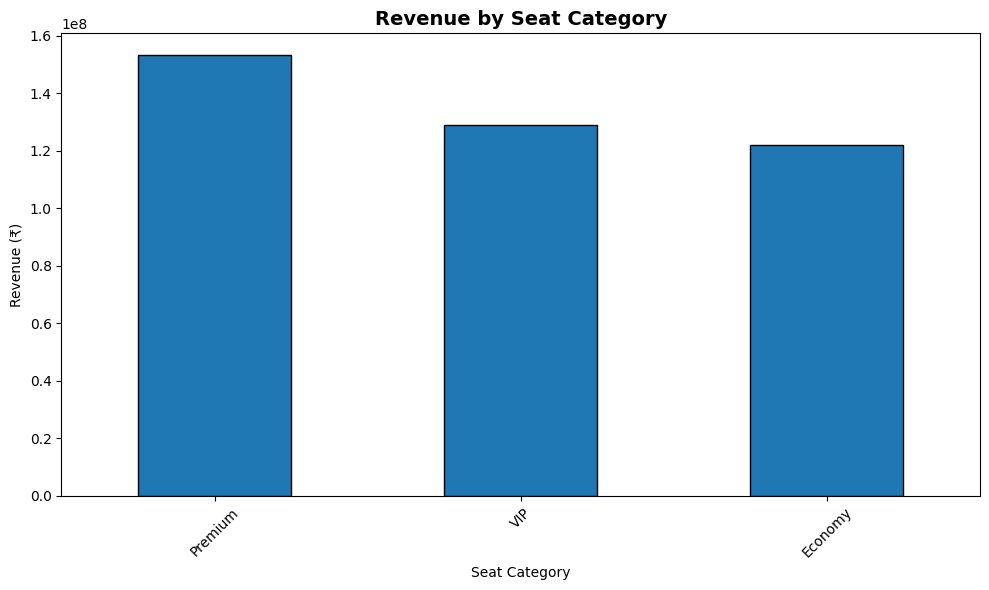

revenue_by_seat_category.png saved successfully.


In [21]:
create_bar_chart(
    data=seat_revenue,
    title="Revenue by Seat Category",
    xlabel="Seat Category",
    ylabel="Revenue (₹)",
    filename="revenue_by_seat_category.png"
)

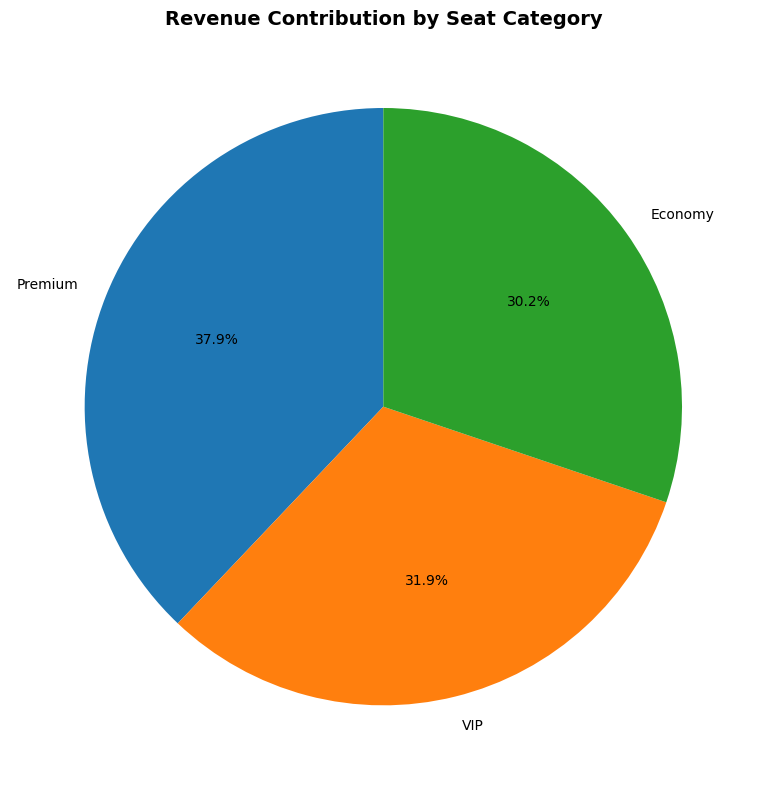

✓ revenue_by_seat_category_pie.png saved successfully


In [22]:
create_pie_chart(
    data=seat_revenue,
    title="Revenue Contribution by Seat Category",
    filename="revenue_by_seat_category_pie.png"
)

In [23]:
highest_category = seat_revenue.idxmax()

highest_revenue = seat_revenue.max()

print("Highest Revenue Category :", highest_category)

print("Revenue Generated : ₹{:,.0f}".format(highest_revenue))

Highest Revenue Category : Premium
Revenue Generated : ₹153,212,000


### Business Insight

- Premium seating categories contribute significantly more revenue because of their higher ticket prices.
- Economy seating generates a large booking volume but lower revenue per ticket.
- Revenue is concentrated among higher-priced seating categories.

## Query 2

### Business Question

Which match type generates the highest revenue?

### Objective

To compare revenue generated by different match types and identify the most profitable fixtures.

In [19]:
match_type_revenue = (
    sales_data
    .groupby("Match_Type")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(match_type_revenue)

Match_Type
League         381760800
Final            5631600
Qualifier 2      5581000
Qualifier 1      5577800
Eliminator       5484800
Name: Total_Amount, dtype: int64

In [20]:
match_type_percentage = (
    match_type_revenue
    / match_type_revenue.sum()
    *100
).round(2)

display(match_type_percentage)

Match_Type
League         94.49
Final           1.39
Qualifier 2     1.38
Qualifier 1     1.38
Eliminator      1.36
Name: Total_Amount, dtype: float64

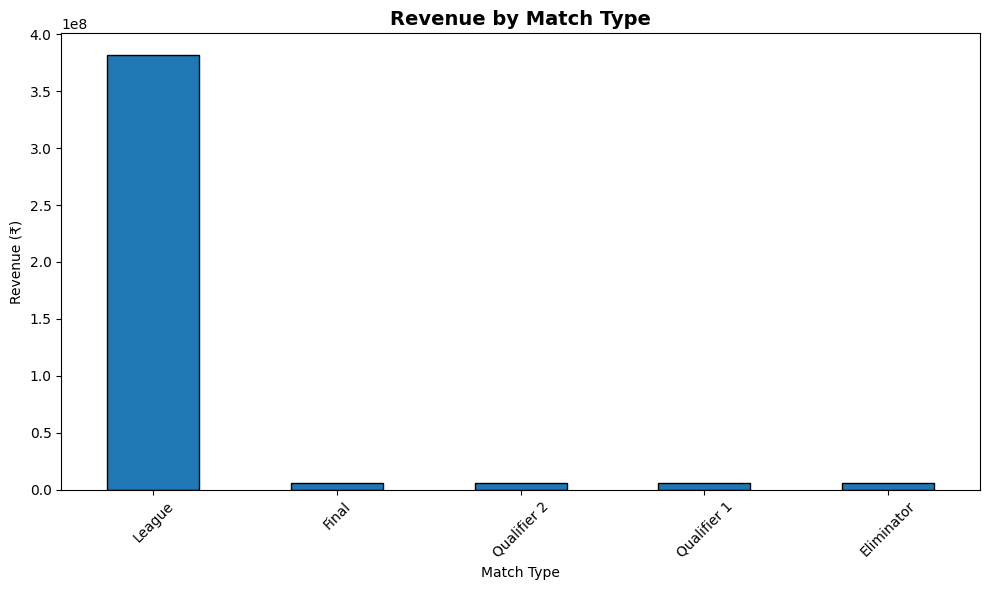

match_type_revenue_bar.png saved successfully.


In [21]:
create_bar_chart(
    data=match_type_revenue,
    title="Revenue by Match Type",
    xlabel="Match Type",
    ylabel="Revenue (₹)",
    filename="match_type_revenue_bar.png"
)

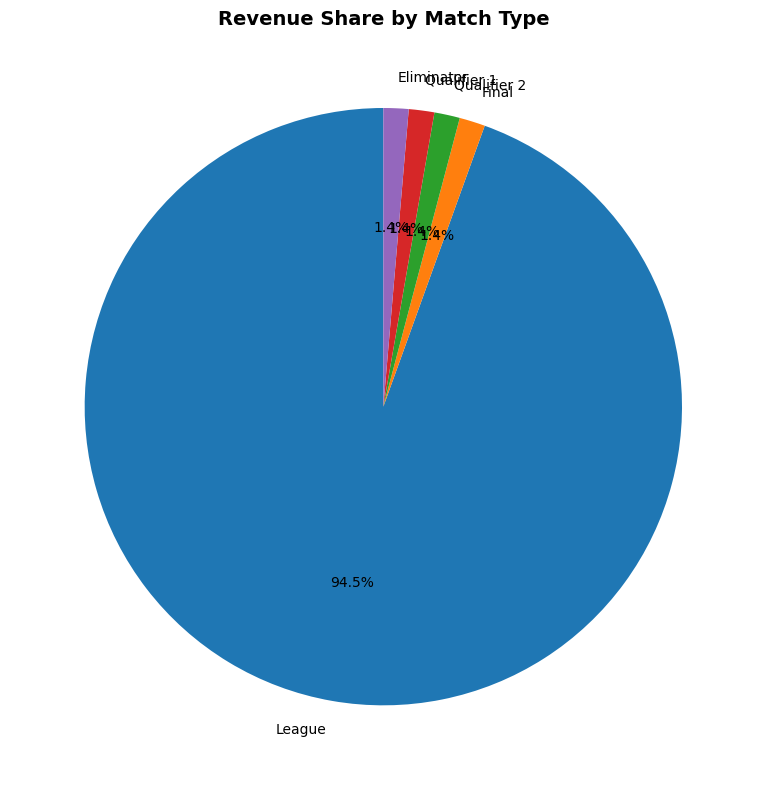

✓ match_type_revenue_pie.png saved successfully


In [22]:
create_pie_chart(
    data=match_type_revenue,
    title="Revenue Share by Match Type",
    filename="match_type_revenue_pie.png"
)

In [23]:
highest_match = match_type_revenue.idxmax()

highest_value = match_type_revenue.max()

print("Highest Revenue Match Type :", highest_match)

print("Revenue : ₹{:,.0f}".format(highest_value))

Highest Revenue Match Type : League
Revenue : ₹381,760,800


### Business Insight

- High-profile match types generally generate higher ticket revenue because of stronger fan demand.
- Revenue distribution helps prioritize premium pricing strategies for marquee fixtures.

## Query 3

### Business Question

Which venues generate the highest ticket revenue?

### Objective

To identify the most profitable IPL venues based on total ticket revenue.

In [24]:
venue_revenue = (
    sales_data
    .groupby("Venue")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(venue_revenue)

Venue
Rajiv Gandhi International Stadium    49142400
Sawai Mansingh Stadium                48944000
Narendra Modi Stadium                 44540600
M. Chinnaswamy Stadium                43767400
Arun Jaitley Stadium                  43766800
M. A. Chidambaram Stadium             43752200
Punjab Cricket Association Stadium    38114400
BRSABV Ekana Stadium                  37777800
Wankhede Stadium                      32522800
Eden Gardens                          21707600
Name: Total_Amount, dtype: int64

In [25]:
venue_revenue_percentage = (
    venue_revenue
    / venue_revenue.sum()
    *100
).round(2)

display(venue_revenue_percentage)

Venue
Rajiv Gandhi International Stadium    12.16
Sawai Mansingh Stadium                12.11
Narendra Modi Stadium                 11.02
M. Chinnaswamy Stadium                10.83
Arun Jaitley Stadium                  10.83
M. A. Chidambaram Stadium             10.83
Punjab Cricket Association Stadium     9.43
BRSABV Ekana Stadium                   9.35
Wankhede Stadium                       8.05
Eden Gardens                           5.37
Name: Total_Amount, dtype: float64

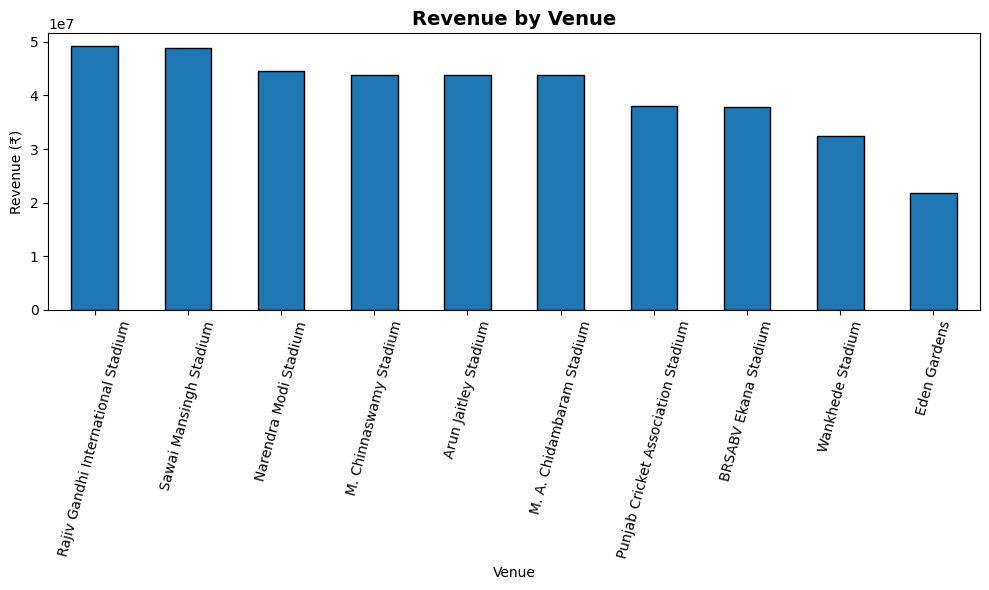

venue_revenue_bar.png saved successfully.


In [26]:
create_bar_chart(
    data=venue_revenue,
    title="Revenue by Venue",
    xlabel="Venue",
    ylabel="Revenue (₹)",
    filename="venue_revenue_bar.png",
    rotation=75
)

In [27]:
highest_venue = venue_revenue.idxmax()

highest_venue_revenue = venue_revenue.max()

print("Highest Revenue Venue :", highest_venue)

print(f"Revenue : ₹{highest_venue_revenue:,.0f}")

Highest Revenue Venue : Rajiv Gandhi International Stadium
Revenue : ₹49,142,400


### Business Insight

- A small number of venues contribute a significant portion of total ticket revenue.
- High-performing venues typically host high-demand matches and have larger seating capacities.


## Query 4

### Business Question

Which cities contribute the highest ticket revenue?

### Objective

To identify cities with the highest revenue contribution and support regional marketing strategies.

In [33]:
sales_data = (
    ticket_sales
    .merge(
        matches,
        on="Match_ID",
        how="left",
        suffixes=("", "_match")
    )
    .merge(
        customers,
        on="Customer_ID",
        how="left",
        suffixes=("", "_customer")
    )
)

display(sales_data.head())

,Ticket_ID,Customer_ID,Match_ID,Booking_Date,Seat_Category,Ticket_Price,Quantity,Total_Amount,Payment_Method,Booking_Status,Match_Date,Season,Home_Team,Away_Team,Venue,City,Match_Type,Stadium_Capacity,VIP_Capacity,Premium_Capacity,Economy_Capacity,First_Name,Last_Name,Gender,Age,Date_of_Birth,City_customer,State,Favorite_Team,Occupation,Annual_Income,Loyalty_Tier,Email,Phone,Registration_Date
0,T000001,C10477,M009,2026-03-28,Economy,800,1,800,UPI,Confirmed,2026-04-05,IPL 2026,SRH,RR,Rajiv Gandhi International Stadium,Hyderabad,League,55000,3000,12000,40000,Netra,Narang,Female,33,1993-04-02,Bengaluru,Karnataka,KKR,Nurse,329967,Bronze,netra.narang790@outlook.com,8904618696,2024-09-12
1,T000002,C11088,M039,2026-03-18,Premium,2000,1,2000,UPI,Confirmed,2026-05-05,IPL 2026,RCB,DC,M. Chinnaswamy Stadium,Bengaluru,League,40000,2500,9000,28500,Peter,Nath,Male,55,1971-11-12,Mohali,Punjab,RCB,Police Officer,467400,Silver,peter.nath759@outlook.com,7963916621,2024-06-24
2,T000003,C03583,M029,2026-04-10,Economy,800,1,800,UPI,Confirmed,2026-04-25,IPL 2026,KKR,SRH,Eden Gardens,Kolkata,League,68000,3500,15000,49500,Sanya,Grover,Female,19,2007-11-26,Bengaluru,Karnataka,SRH,Police Officer,516254,Silver,sanya.grover701@hotmail.com,6785351562,2025-03-04
3,T000004,C08929,M002,2026-03-02,Economy,800,2,1600,Debit Card,Confirmed,2026-03-29,IPL 2026,MI,RCB,Wankhede Stadium,Mumbai,League,33000,1800,7000,24200,Wriddhish,Rajagopalan,Male,36,1990-08-18,Hyderabad,Telangana,MI,Chartered Accountant,2192494,Silver,wriddhish.rajagopalan511@outlook.com,7430869547,2024-11-30
4,T000005,C02616,M036,2026-03-18,Economy,800,1,800,UPI,Confirmed,2026-05-02,IPL 2026,GT,RR,Narendra Modi Stadium,Ahmedabad,League,132000,6000,26000,100000,Saumya,Tailor,Female,52,1974-10-10,Lucknow,Uttar Pradesh,RR,Police Officer,490251,Silver,saumya.tailor783@hotmail.com,7739250144,2025-01-22


In [34]:
city_revenue = (
    sales_data
    .groupby("City")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(city_revenue)

City
Hyderabad    49142400
Jaipur       48944000
Ahmedabad    44540600
Bengaluru    43767400
Delhi        43766800
Chennai      43752200
Mohali       38114400
Lucknow      37777800
Mumbai       32522800
Kolkata      21707600
Name: Total_Amount, dtype: int64

In [35]:
city_revenue_percentage = (
    city_revenue
    / city_revenue.sum()
    *100
).round(2)

display(city_revenue_percentage)

City
Hyderabad    12.16
Jaipur       12.11
Ahmedabad    11.02
Bengaluru    10.83
Delhi        10.83
Chennai      10.83
Mohali        9.43
Lucknow       9.35
Mumbai        8.05
Kolkata       5.37
Name: Total_Amount, dtype: float64

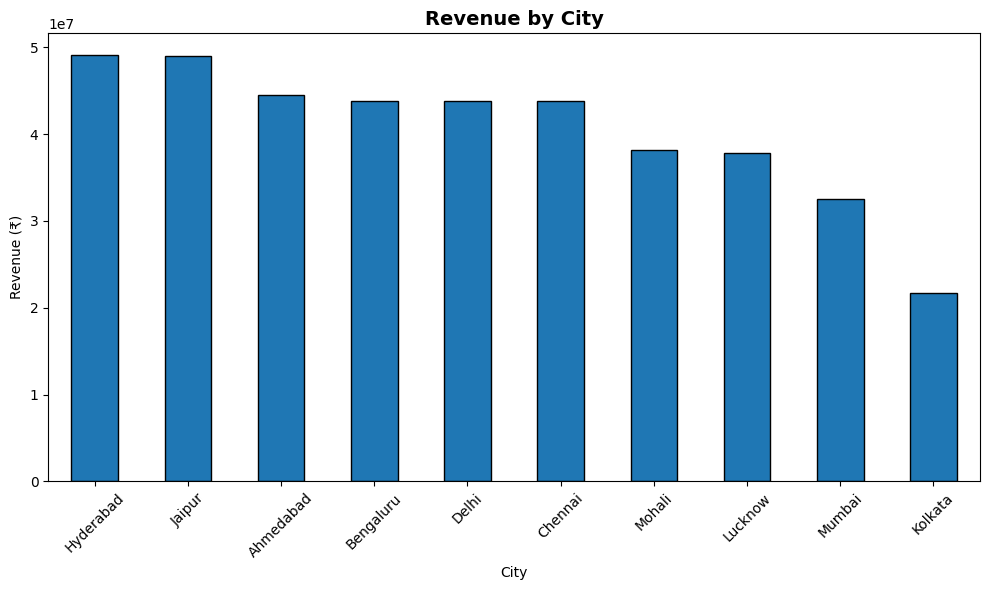

city_revenue_bar.png saved successfully.


In [36]:
create_bar_chart(
    data=city_revenue,
    title="Revenue by City",
    xlabel="City",
    ylabel="Revenue (₹)",
    filename="city_revenue_bar.png"
)

In [37]:
highest_city = city_revenue.idxmax()

highest_city_revenue = city_revenue.max()

print("Highest Revenue City :", highest_city)

print(f"Revenue : ₹{highest_city_revenue:,.0f}")

Highest Revenue City : Hyderabad
Revenue : ₹49,142,400


### Business Insight

- Cities with stronger fan engagement contribute significantly more ticket revenue.
- Revenue concentration can help identify priority markets for promotional campaigns.

### Recommendation

- Focus marketing efforts and fan engagement activities in high-revenue cities while exploring opportunities to grow ticket sales in lower-performing markets.

## Query 5

### Business Question

Which payment methods generate the highest ticket revenue?

### Objective

To understand customer payment preferences and identify payment channels contributing the most revenue.

In [38]:
payment_revenue = (
    sales_data
    .groupby("Payment_Method")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(payment_revenue)

Payment_Method
UPI            181487800
Credit Card    102260600
Debit Card      80460400
Net Banking     39827200
Name: Total_Amount, dtype: int64

In [39]:
payment_revenue_percentage = (
    payment_revenue
    / payment_revenue.sum()
    *100
).round(2)

display(payment_revenue_percentage)

Payment_Method
UPI            44.92
Credit Card    25.31
Debit Card     19.91
Net Banking     9.86
Name: Total_Amount, dtype: float64

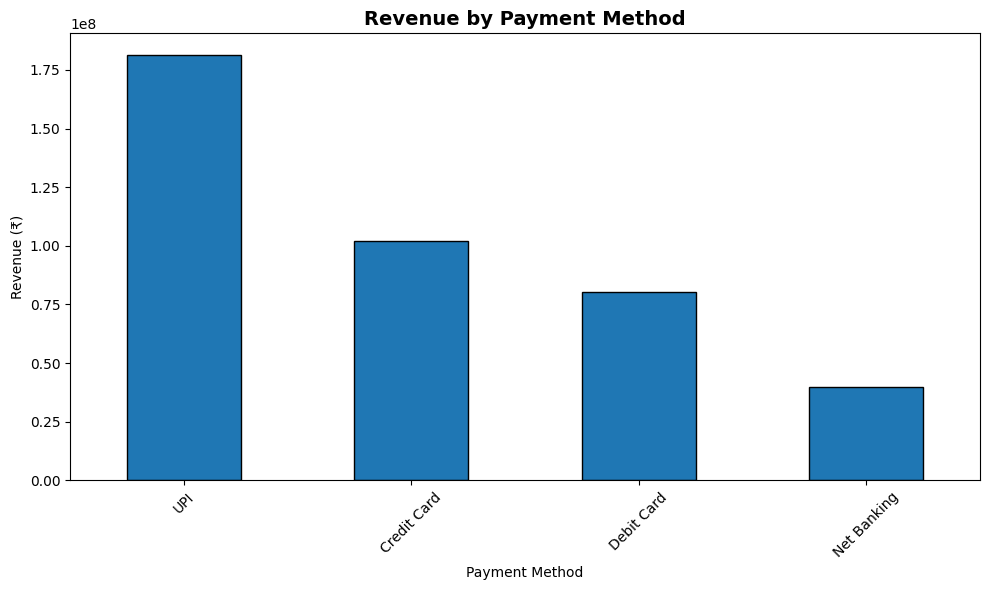

payment_method_revenue_bar.png saved successfully.


In [40]:
create_bar_chart(
    data=payment_revenue,
    title="Revenue by Payment Method",
    xlabel="Payment Method",
    ylabel="Revenue (₹)",
    filename="payment_method_revenue_bar.png"
)

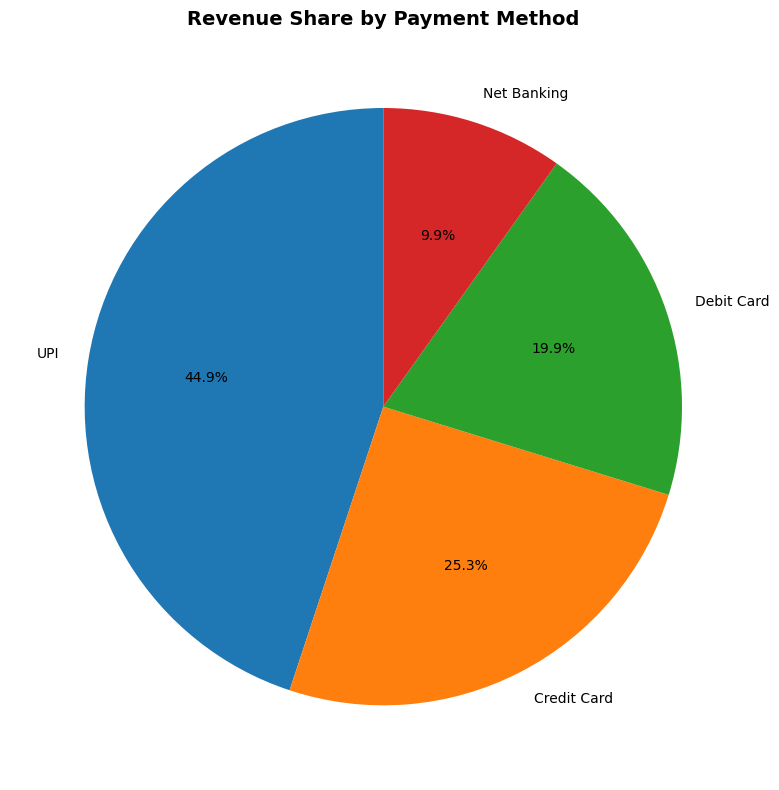

✓ payment_method_revenue_pie.png saved successfully


In [41]:
create_pie_chart(
    data=payment_revenue,
    title="Revenue Share by Payment Method",
    filename="payment_method_revenue_pie.png"
)

In [42]:
highest_payment = payment_revenue.idxmax()

highest_payment_revenue = payment_revenue.max()

print("Highest Revenue Payment Method :", highest_payment)

print(f"Revenue : ₹{highest_payment_revenue:,.0f}")

Highest Revenue Payment Method : UPI
Revenue : ₹181,487,800


### Business Insight

- Digital payment methods contribute a significant share of ticket revenue, reflecting customer preference for convenient and secure transactions.
- Understanding payment trends supports payment gateway optimization and promotional planning.

### Recommendation

- Strengthen partnerships with popular payment providers and introduce payment-specific offers to improve customer experience and maximize revenue.

# Module 2 : Customer Behaviour Analysis

## Query 6

### Business Question

Which loyalty tier generates the highest revenue?

### Objective

To identify the customer loyalty segment contributing the most revenue and understand spending behavior across different membership tiers.

In [43]:
loyalty_revenue = (
    sales_data
    .groupby("Loyalty_Tier")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(loyalty_revenue)

Loyalty_Tier
Bronze      204670000
Silver      118522200
Gold         61143000
Platinum     19700800
Name: Total_Amount, dtype: int64

In [44]:
loyalty_percentage = (
    loyalty_revenue
    / loyalty_revenue.sum()
    * 100
).round(2)

display(loyalty_percentage)

Loyalty_Tier
Bronze      50.66
Silver      29.33
Gold        15.13
Platinum     4.88
Name: Total_Amount, dtype: float64

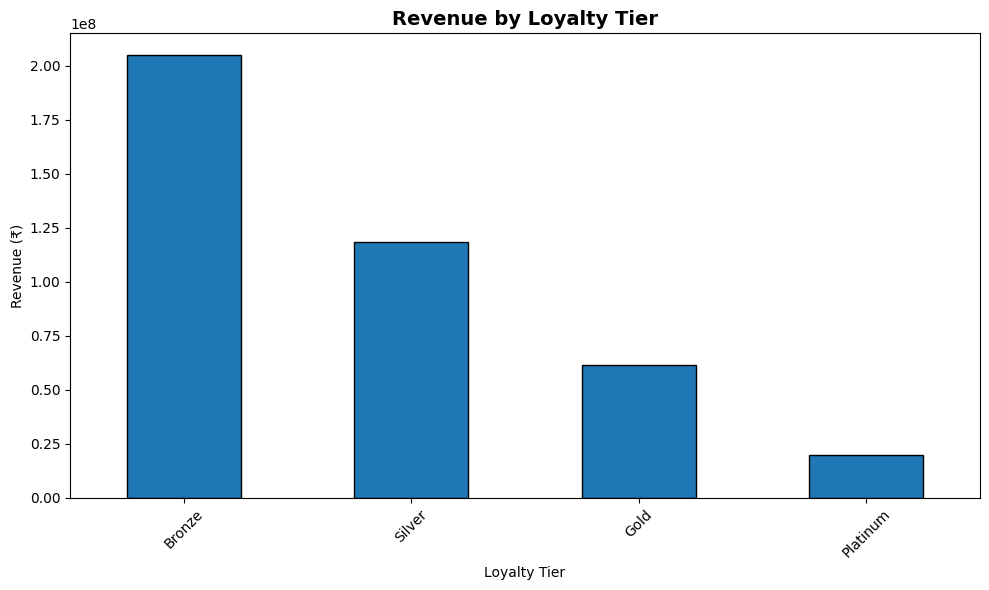

loyalty_revenue_bar.png saved successfully.


In [45]:
create_bar_chart(
    data=loyalty_revenue,
    title="Revenue by Loyalty Tier",
    xlabel="Loyalty Tier",
    ylabel="Revenue (₹)",
    filename="loyalty_revenue_bar.png"
)

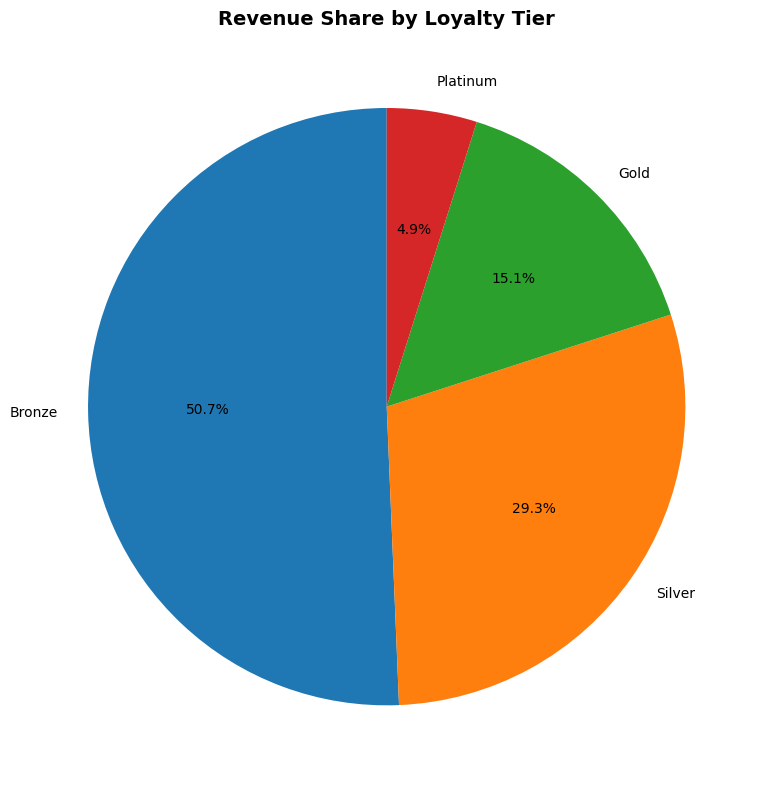

✓ loyalty_revenue_pie.png saved successfully


In [46]:
create_pie_chart(
    data=loyalty_revenue,
    title="Revenue Share by Loyalty Tier",
    filename="loyalty_revenue_pie.png"
)

In [47]:
highest_loyalty = loyalty_revenue.idxmax()

highest_revenue = loyalty_revenue.max()

print("Highest Revenue Loyalty Tier :", highest_loyalty)
print(f"Revenue : ₹{highest_revenue:,.0f}")

Highest Revenue Loyalty Tier : Bronze
Revenue : ₹204,670,000


### Business Insight

- Higher loyalty tiers generally contribute greater revenue because of increased customer engagement and repeat purchases.
- Loyalty programs play a significant role in customer retention and revenue generation.

### Recommendation

- Introduce exclusive rewards and targeted promotions to encourage Bronze customers to upgrade into higher loyalty tiers.

## Query 7

### Business Question

Which age group contributes the highest ticket revenue?

### Objective

To identify the most valuable customer age segment for targeted marketing and promotional strategies.

In [49]:
sales_data["Age_Group"] = pd.cut(
    sales_data["Age"],
    bins=[0,18,25,35,45,60,100],
    labels=[
        "Below 18",
        "19-25",
        "26-35",
        "36-45",
        "46-60",
        "60+"
    ]
)

In [50]:
age_revenue = (
    sales_data
    .groupby("Age_Group")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(age_revenue)

C:\Users\venka\AppData\Local\Temp\ipykernel_7740\3609896236.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Age_Group")["Total_Amount"]


Age_Group
26-35       136921000
19-25       100989000
36-45        92543600
46-60        58073400
Below 18     15509000
60+                 0
Name: Total_Amount, dtype: int64

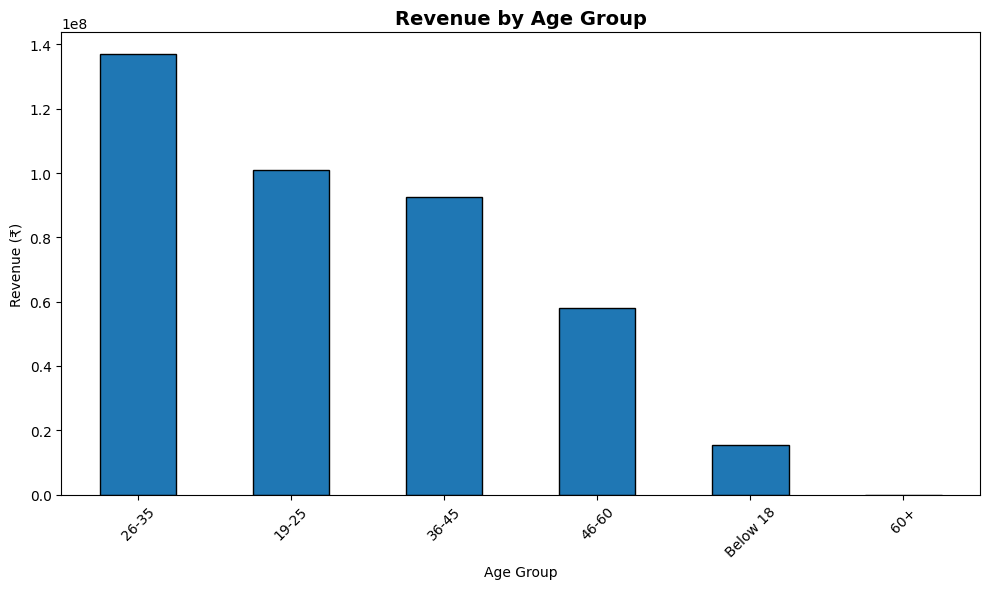

age_group_revenue_bar.png saved successfully.


In [51]:
create_bar_chart(
    data=age_revenue,
    title="Revenue by Age Group",
    xlabel="Age Group",
    ylabel="Revenue (₹)",
    filename="age_group_revenue_bar.png"
)

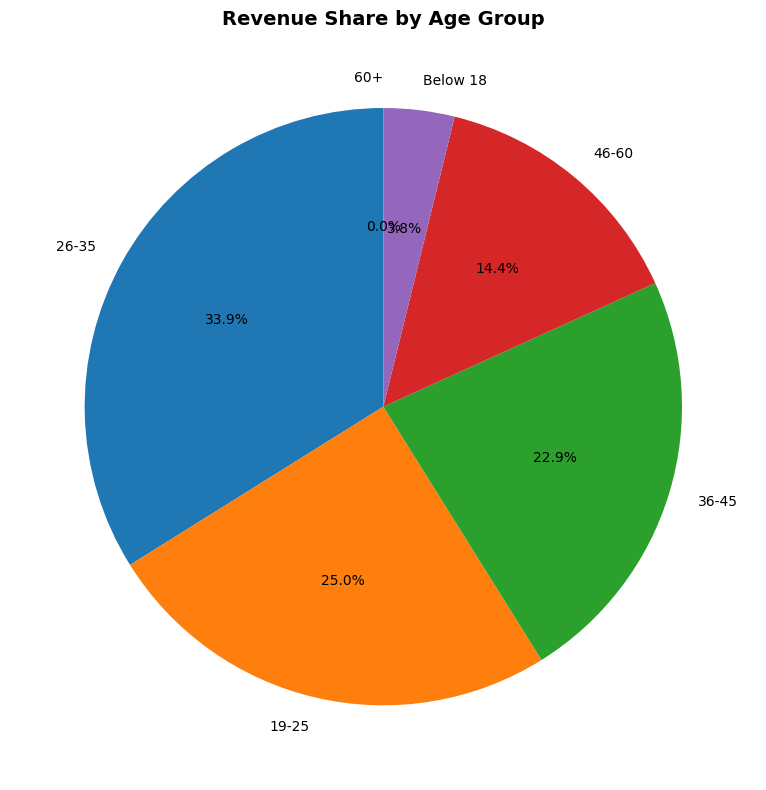

✓ age_group_revenue_pie.png saved successfully


In [52]:
create_pie_chart(
    data=age_revenue,
    title="Revenue Share by Age Group",
    filename="age_group_revenue_pie.png"
)

### Business Insight

- Certain age groups contribute significantly more revenue than others.
- Identifying the highest-spending age segment enables more focused marketing campaigns and customer engagement strategies.

### Recommendation

- Develop personalized campaigns and promotional offers tailored to the highest-value age groups while creating engagement initiatives for underrepresented segments.

## Query 8

### Business Question

How does ticket revenue vary by customer gender?

### Objective

To compare revenue contribution across customer genders and identify differences in purchasing behavior.

In [53]:
gender_revenue = (
    sales_data
    .groupby("Gender")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(gender_revenue)

Gender
Male      260967800
Female    143068200
Name: Total_Amount, dtype: int64

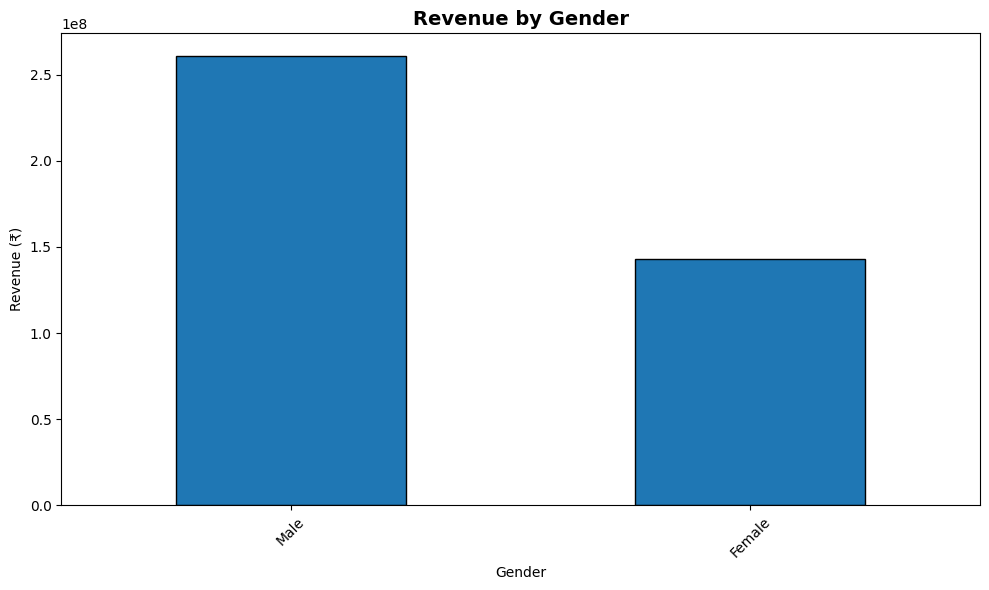

gender_revenue_bar.png saved successfully.


In [54]:
create_bar_chart(
    data=gender_revenue,
    title="Revenue by Gender",
    xlabel="Gender",
    ylabel="Revenue (₹)",
    filename="gender_revenue_bar.png"
)

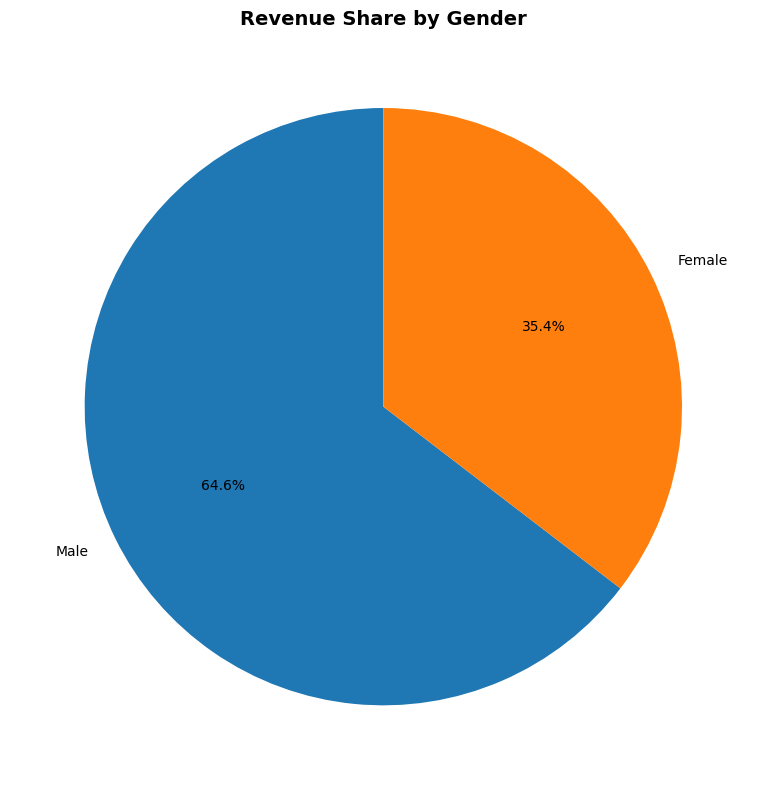

✓ gender_revenue_pie.png saved successfully


In [55]:
create_pie_chart(
    data=gender_revenue,
    title="Revenue Share by Gender",
    filename="gender_revenue_pie.png"
)

### Business Insight

- Revenue contribution varies across customer genders, providing insights into audience participation and purchasing trends.
- Understanding these patterns supports inclusive marketing and promotional planning.

### Recommendation

- Design balanced marketing campaigns that appeal to all customer groups while strengthening engagement with underrepresented segments.

## Query 9

### Business Question

Which IPL team's fans generate the highest ticket revenue?

### Objective

To identify which team's supporters contribute the highest revenue and understand fan purchasing behavior across franchises.

In [57]:
favorite_team_revenue = (
    sales_data
    .groupby("Favorite_Team")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(favorite_team_revenue)

Favorite_Team
RCB     57582600
MI      56112400
CSK     55944200
KKR     48737200
SRH     40040800
RR      32830200
DC      31834000
LSG     29796600
GT      27754000
PBKS    23404000
Name: Total_Amount, dtype: int64

In [58]:
favorite_team_percentage = (
    favorite_team_revenue
    / favorite_team_revenue.sum()
    * 100
).round(2)

display(favorite_team_percentage)

Favorite_Team
RCB     14.25
MI      13.89
CSK     13.85
KKR     12.06
SRH      9.91
RR       8.13
DC       7.88
LSG      7.37
GT       6.87
PBKS     5.79
Name: Total_Amount, dtype: float64

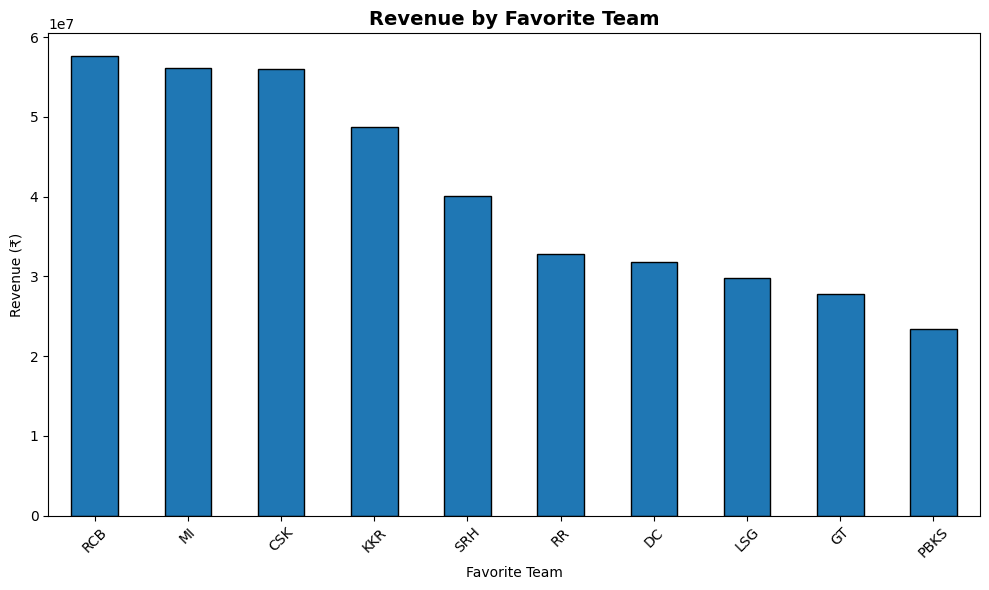

favorite_team_revenue_bar.png saved successfully.


In [59]:
create_bar_chart(
    data=favorite_team_revenue,
    title="Revenue by Favorite Team",
    xlabel="Favorite Team",
    ylabel="Revenue (₹)",
    filename="favorite_team_revenue_bar.png"
)

In [60]:
highest_team = favorite_team_revenue.idxmax()

highest_team_revenue = favorite_team_revenue.max()

print("Highest Revenue Generating Fan Base :", highest_team)

print(f"Revenue : ₹{highest_team_revenue:,.0f}")

Highest Revenue Generating Fan Base : RCB
Revenue : ₹57,582,600


### Business Insight

- Fans of certain IPL franchises contribute significantly higher ticket revenue than others.
- Team popularity has a direct impact on ticket demand and overall revenue generation.
- Understanding fan spending patterns supports franchise-specific marketing initiatives.

### Recommendation

- Introduce team-specific promotions, merchandise bundles, and exclusive fan experiences for franchises with high-spending supporters to maximize customer engagement and revenue.

## Query 10

### Business Question

Which customer occupations generate the highest ticket revenue?

### Objective

To identify professional segments with the highest spending capacity and support customer segmentation strategies.

In [61]:
occupation_revenue = (
    sales_data
    .groupby("Occupation")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(occupation_revenue)

Occupation
Chartered Accountant    21482400
Freelancer              21368000
Software Engineer       21227800
Marketing Executive     20694600
Business Owner          20596200
Student                 20594000
Data Analyst            20455400
Government Employee     20442800
Entrepreneur            20319800
Data Scientist          20158400
Doctor                  20129000
Graphic Designer        20082600
Sales Executive         19931800
Police Officer          19880200
Mechanical Engineer     19799600
Nurse                   19683600
Lawyer                  19497400
Teacher                 19461400
Banker                  19186200
Civil Engineer          19044800
Name: Total_Amount, dtype: int64

In [62]:
top_10_occupation_revenue = occupation_revenue.head(10)

display(top_10_occupation_revenue)

Occupation
Chartered Accountant    21482400
Freelancer              21368000
Software Engineer       21227800
Marketing Executive     20694600
Business Owner          20596200
Student                 20594000
Data Analyst            20455400
Government Employee     20442800
Entrepreneur            20319800
Data Scientist          20158400
Name: Total_Amount, dtype: int64

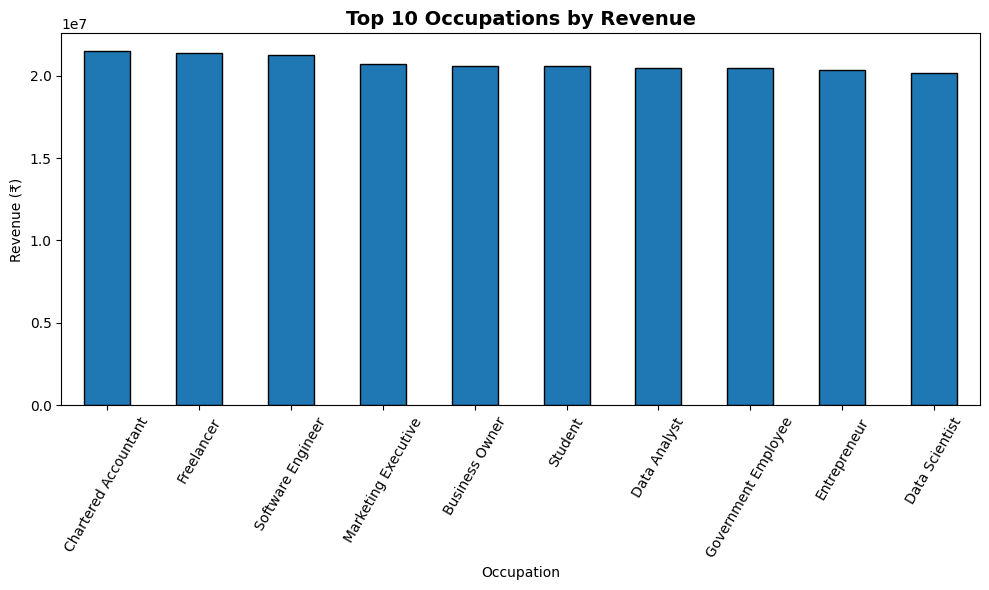

occupation_revenue_bar.png saved successfully.


In [63]:
create_bar_chart(
    data=top_10_occupation_revenue,
    title="Top 10 Occupations by Revenue",
    xlabel="Occupation",
    ylabel="Revenue (₹)",
    filename="occupation_revenue_bar.png",
    rotation=60
)

In [64]:
highest_occupation = occupation_revenue.idxmax()

highest_occupation_revenue = occupation_revenue.max()

print("Highest Revenue Generating Occupation :", highest_occupation)

print(f"Revenue : ₹{highest_occupation_revenue:,.0f}")

Highest Revenue Generating Occupation : Chartered Accountant
Revenue : ₹21,482,400


# Module 3 : Booking Behaviour Analysis

## Query 11

### Business Question

How does booking lead time influence ticket revenue?

### Objective

To identify whether customers who book earlier contribute more revenue than last-minute buyers.

In [15]:
sales_data[["Match_Date", "Booking_Date"]].dtypes

Match_Date      object
Booking_Date    object
dtype: object

In [16]:
# Convert date columns to datetime

sales_data["Match_Date"] = pd.to_datetime(
    sales_data["Match_Date"],
    errors="coerce"
)

sales_data["Booking_Date"] = pd.to_datetime(
    sales_data["Booking_Date"],
    errors="coerce"
)

print(sales_data[["Match_Date", "Booking_Date"]].dtypes)

Match_Date      datetime64[ns]
Booking_Date    datetime64[ns]
dtype: object


In [17]:
sales_data["Lead_Time"] = (
    sales_data["Match_Date"] -
    sales_data["Booking_Date"]
).dt.days

display(sales_data[["Booking_Date","Match_Date","Lead_Time"]].head())

,Booking_Date,Match_Date,Lead_Time
0,2026-03-28,2026-04-05,8
1,2026-03-18,2026-05-05,48
2,2026-04-10,2026-04-25,15
3,2026-03-02,2026-03-29,27
4,2026-03-18,2026-05-02,45


In [18]:
sales_data["Lead_Time_Bucket"] = pd.cut(
    sales_data["Lead_Time"],
    bins=[-1,3,7,15,30,365],
    labels=[
        "0-3 Days",
        "4-7 Days",
        "8-15 Days",
        "16-30 Days",
        "30+ Days"
    ]
)

In [19]:
lead_time_revenue = (
    sales_data
    .groupby("Lead_Time_Bucket")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(lead_time_revenue)

C:\Users\venka\AppData\Local\Temp\ipykernel_26708\1905116477.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Lead_Time_Bucket")["Total_Amount"]


Lead_Time_Bucket
30+ Days      201157600
16-30 Days    101491800
8-15 Days      53580000
4-7 Days       27716400
0-3 Days       20090200
Name: Total_Amount, dtype: int64

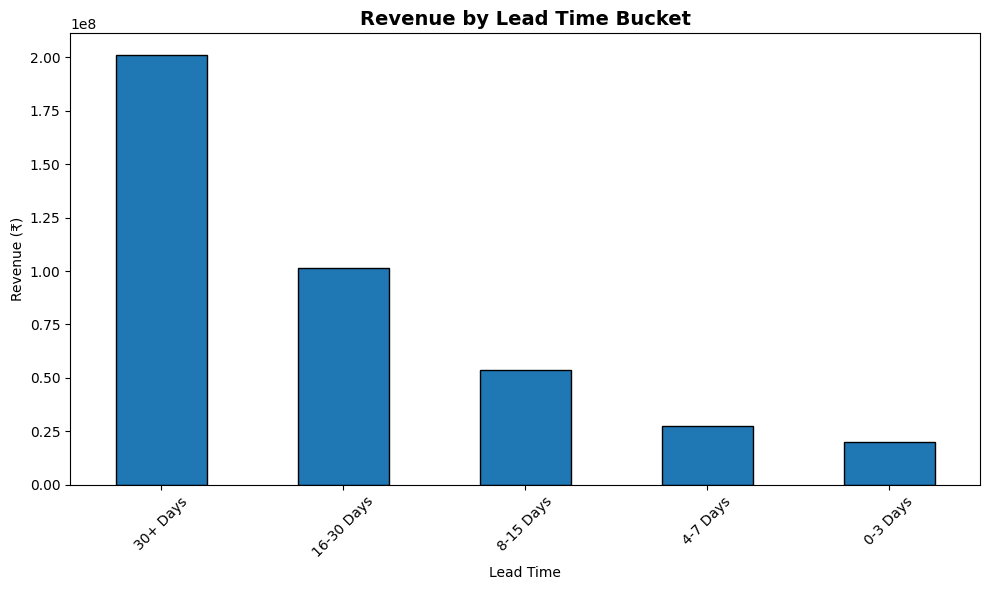

lead_time_revenue_bar.png saved successfully.


In [20]:
create_bar_chart(
    data=lead_time_revenue,
    title="Revenue by Lead Time Bucket",
    xlabel="Lead Time",
    ylabel="Revenue (₹)",
    filename="lead_time_revenue_bar.png"
)

### Business Insight

Customers who book earlier generally contribute a significant portion of total ticket revenue.

### Recommendation

Offer early-bird discounts and loyalty rewards to encourage advance bookings and improve revenue predictability.

## Query 12

### Business Question

Which booking months generate the highest revenue?

### Objective

To identify seasonal booking patterns and peak revenue periods.

In [21]:
sales_data["Booking_Month"] = (
    sales_data["Booking_Date"]
    .dt.strftime("%B")
)

In [22]:
month_revenue = (
    sales_data
    .groupby("Booking_Month")["Total_Amount"]
    .sum()
)

month_revenue = month_revenue.reindex([
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]).dropna()

display(month_revenue)

Booking_Month
January       1288400.0
February     49312400.0
March       136893600.0
April       144852000.0
May          67661600.0
June          4028000.0
Name: Total_Amount, dtype: float64

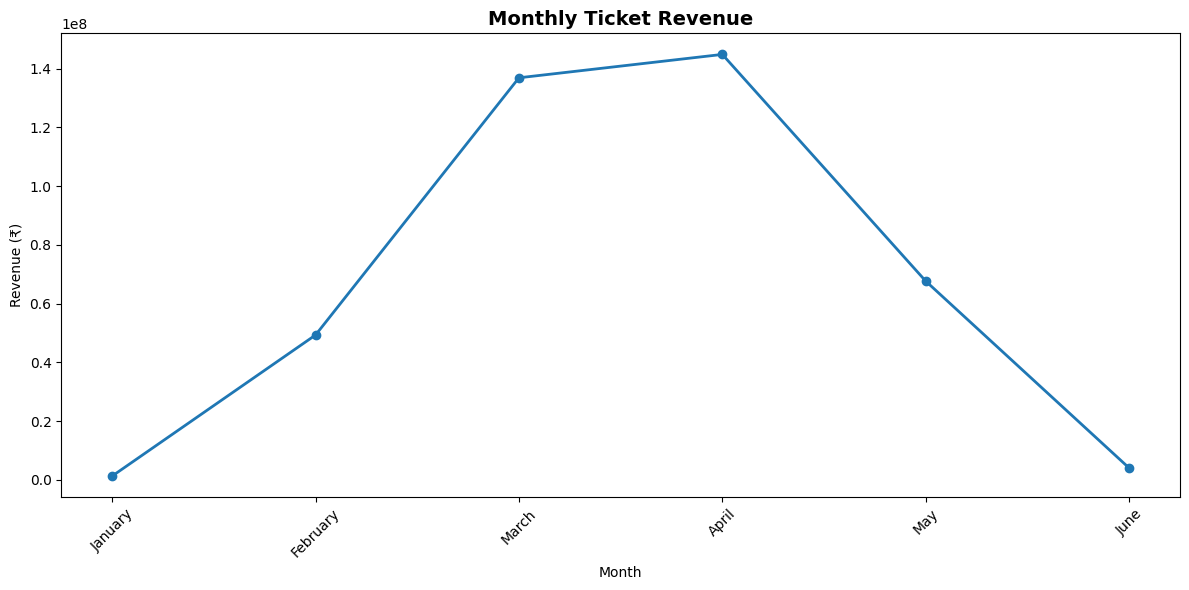

✓ monthly_revenue_line.png saved successfully


In [23]:
create_line_chart(
    data=month_revenue,
    title="Monthly Ticket Revenue",
    xlabel="Month",
    ylabel="Revenue (₹)",
    filename="monthly_revenue_line.png"
)

### Business Insight

Revenue peaks during months with higher IPL activity and ticket demand.

### Recommendation

Increase promotional campaigns before peak booking months to maximize sales.

## Query 13

### Business Question

Is there a relationship between ticket quantity and total booking amount?

### Objective

To understand whether larger bookings generate proportionally higher revenue.

In [24]:
display(
    sales_data[
        ["Quantity","Total_Amount"]
    ].corr()
)

,Quantity,Total_Amount
Quantity,1.000000,0.487787
Total_Amount,0.487787,1.000000


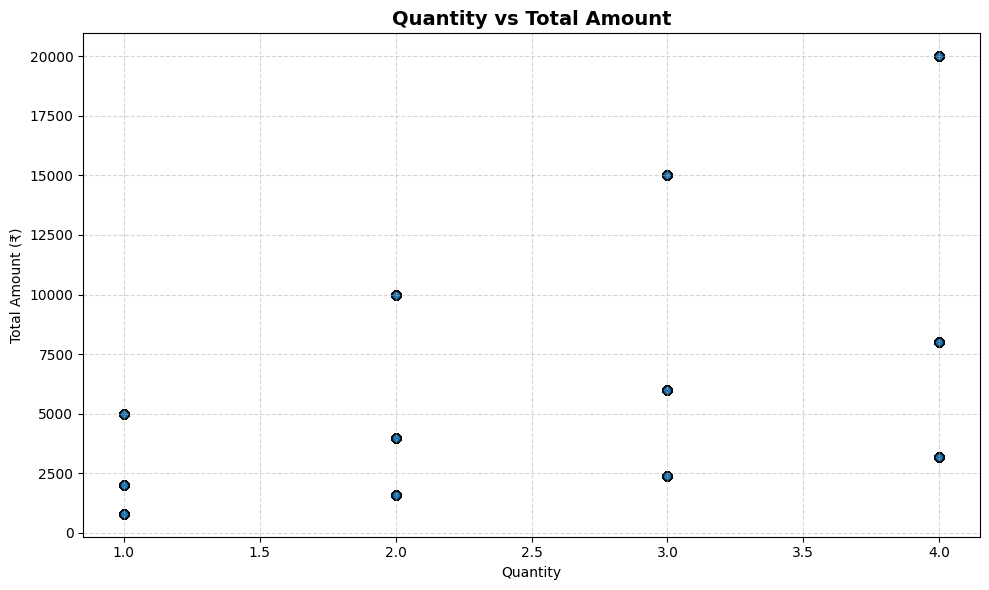

✓ quantity_vs_total_amount.png saved successfully


In [28]:
create_scatter_plot(
    x=sales_data["Quantity"],
    y=sales_data["Total_Amount"],
    title="Quantity vs Total Amount",
    xlabel="Quantity",
    ylabel="Total Amount (₹)",
    filename="quantity_vs_total_amount.png"
)


### Business Insight

Larger ticket quantities generally result in higher booking values, indicating strong group booking potential.

### Recommendation

Introduce family and corporate ticket packages to encourage larger bookings.

## Query 14

### Business Question

How does booking status affect ticket revenue?

### Objective

To analyze the revenue generated from different booking statuses and identify potential revenue loss due to cancellations or pending bookings.

In [29]:
booking_status_revenue = (
    sales_data
    .groupby("Booking_Status")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(booking_status_revenue)

Booking_Status
Confirmed    384361400
Cancelled     19674600
Name: Total_Amount, dtype: int64

In [30]:
booking_status_percentage = (
    booking_status_revenue
    / booking_status_revenue.sum()
    * 100
).round(2)

display(booking_status_percentage)

Booking_Status
Confirmed    95.13
Cancelled     4.87
Name: Total_Amount, dtype: float64

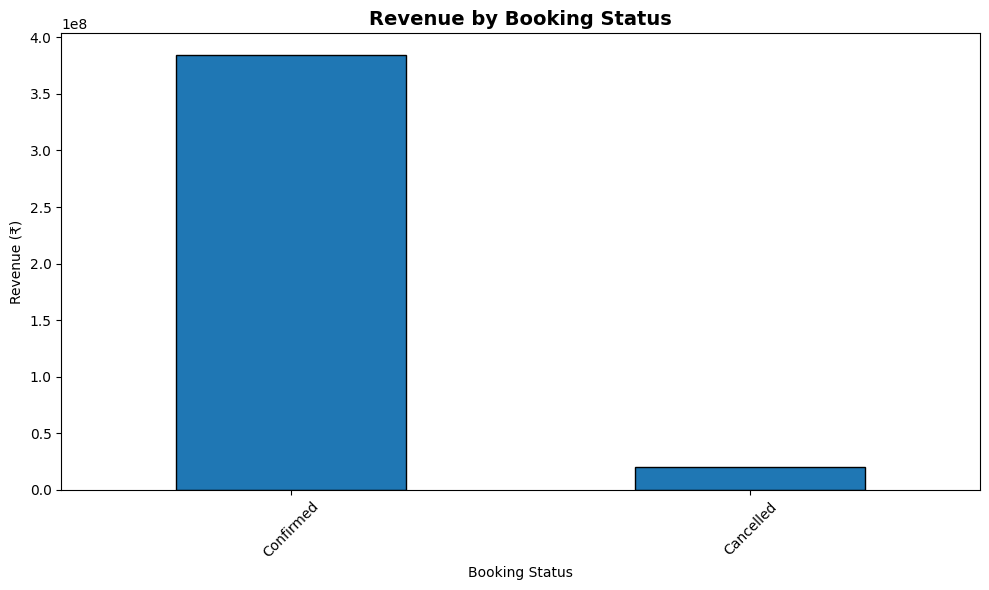

booking_status_revenue_bar.png saved successfully.


In [31]:
create_bar_chart(
    data=booking_status_revenue,
    title="Revenue by Booking Status",
    xlabel="Booking Status",
    ylabel="Revenue (₹)",
    filename="booking_status_revenue_bar.png"
)

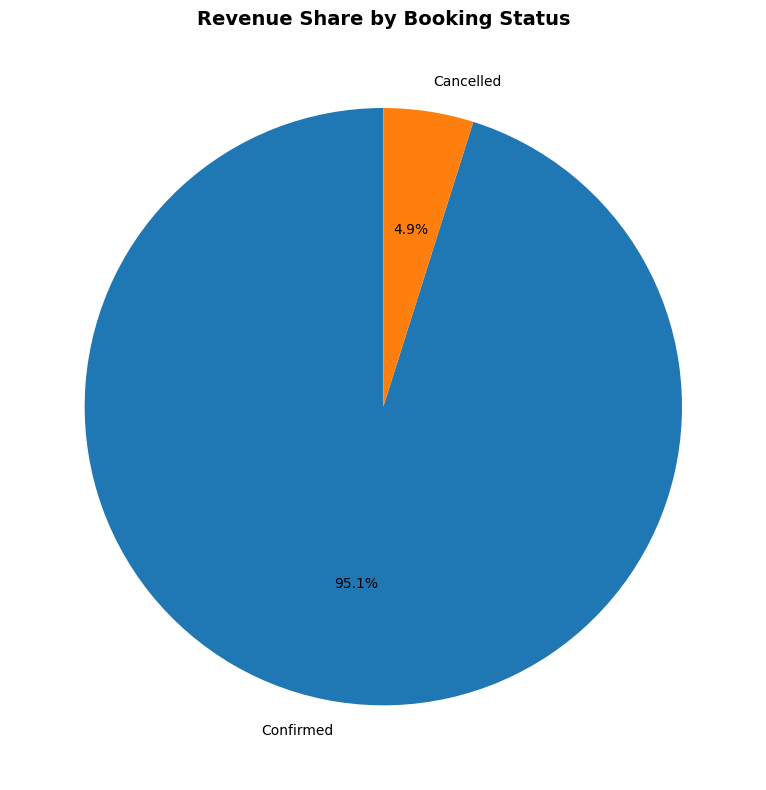

✓ booking_status_revenue_pie.png saved successfully


In [32]:
create_pie_chart(
    data=booking_status_revenue,
    title="Revenue Share by Booking Status",
    filename="booking_status_revenue_pie.png"
)

In [33]:
highest_status = booking_status_revenue.idxmax()

highest_status_revenue = booking_status_revenue.max()

print("Highest Revenue Booking Status :", highest_status)

print(f"Revenue : ₹{highest_status_revenue:,.0f}")

Highest Revenue Booking Status : Confirmed
Revenue : ₹384,361,400


### Business Insight

- Confirmed bookings contribute the majority of ticket revenue.
- Cancelled or pending bookings represent potential revenue leakage and operational inefficiencies.

### Recommendation

- Implement reminder notifications, flexible payment options, and targeted retention campaigns to reduce booking cancellations and improve conversion rates.

## Query 15

### Business Question

Which seat category generates the highest average revenue per booking?

### Objective

To evaluate the revenue efficiency of each seat category by comparing the average booking value across seating types.

In [34]:
average_booking_revenue = (
    sales_data
    .groupby("Seat_Category")["Total_Amount"]
    .mean()
    .sort_values(ascending=False)
)

display(average_booking_revenue)

Seat_Category
VIP        8507.856860
Premium    3403.576586
Economy    1357.584123
Name: Total_Amount, dtype: float64

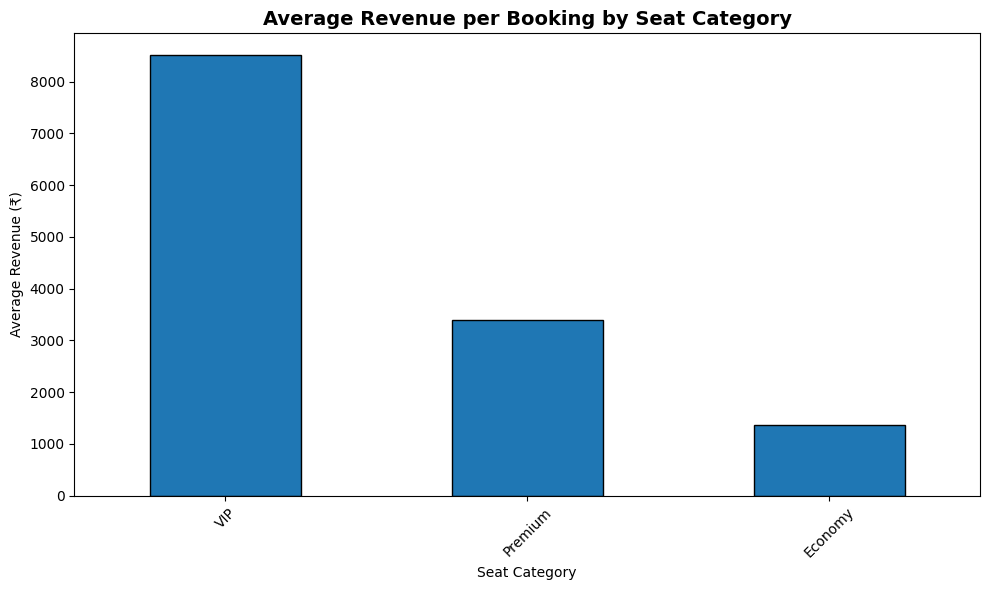

average_revenue_per_booking_seat_category.png saved successfully.


In [35]:
create_bar_chart(
    data=average_booking_revenue,
    title="Average Revenue per Booking by Seat Category",
    xlabel="Seat Category",
    ylabel="Average Revenue (₹)",
    filename="average_revenue_per_booking_seat_category.png"
)

In [36]:
highest_avg_category = average_booking_revenue.idxmax()

highest_avg_revenue = average_booking_revenue.max()

print("Highest Average Revenue Seat Category :", highest_avg_category)

print(f"Average Revenue : ₹{highest_avg_revenue:,.2f}")

Highest Average Revenue Seat Category : VIP
Average Revenue : ₹8,507.86


### Business Insight

- Premium seating categories generate higher average revenue per booking due to their premium pricing and higher customer willingness to pay.
- Economy seating attracts a larger customer base but contributes a lower average booking value.

### Recommendation

- Introduce premium seat upgrades, exclusive match-day experiences, and bundled hospitality packages to increase the average booking value while maintaining affordable options for economy customers.

# Module 4 : Match & Revenue Performance Analytics

## Query 16

### Business Question

Which IPL season generated the highest ticket revenue?

### Objective

To compare revenue across seasons and identify tournament growth trends.

In [37]:
season_revenue = (
    sales_data
    .groupby("Season")["Total_Amount"]
    .sum()
    .sort_values()
)

display(season_revenue)

Season
IPL 2026    404036000
Name: Total_Amount, dtype: int64

In [40]:
highest_season = season_revenue.idxmax()

print("Highest Revenue Season :", highest_season)

print(f"Revenue : ₹{season_revenue.max():,.0f}")

Highest Revenue Season : IPL 2026
Revenue : ₹404,036,000


### Business Insight

- Revenue varies across IPL seasons depending on match popularity, fan engagement, and tournament scheduling.
- Identifying high-performing seasons helps evaluate long-term business growth.

### Recommendation

Analyze the strategies used during the highest-performing season and replicate successful pricing and marketing initiatives in future tournaments.

## Query 17

### Business Question

Which match type generates the highest average booking revenue?

### Objective

To compare average customer spending across different match categories.

In [41]:
match_avg_revenue = (
    sales_data
    .groupby("Match_Type")["Total_Amount"]
    .mean()
    .sort_values(ascending=False)
)

display(match_avg_revenue)

Match_Type
Final          2759.235669
League         2693.615940
Qualifier 1    2690.689822
Eliminator     2667.704280
Qualifier 2    2655.090390
Name: Total_Amount, dtype: float64

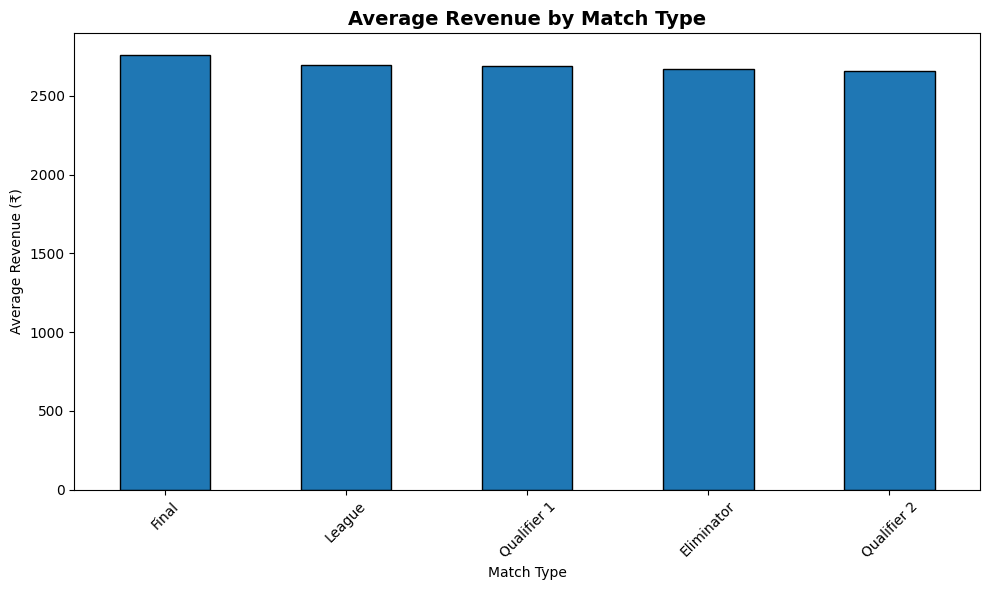

match_type_average_revenue.png saved successfully.


In [42]:
create_bar_chart(
    data=match_avg_revenue,
    title="Average Revenue by Match Type",
    xlabel="Match Type",
    ylabel="Average Revenue (₹)",
    filename="match_type_average_revenue.png"
)

### Business Insight

Premium match categories generally attract customers with higher average spending.

### Recommendation

Adopt differentiated pricing strategies for premium fixtures to maximize revenue without affecting demand.

## Query 18

### Business Question

Which venue utilizes its seating capacity most efficiently?

### Objective

Measure revenue generated per available stadium seat.

In [43]:
venue_efficiency = (
    sales_data
    .groupby(["Venue","Stadium_Capacity"])
    ["Total_Amount"]
    .sum()
    .reset_index()
)

venue_efficiency["Revenue_per_Seat"] = (
    venue_efficiency["Total_Amount"]
    /
    venue_efficiency["Stadium_Capacity"]
)

display(venue_efficiency.head())

,Venue,Stadium_Capacity,Total_Amount,Revenue_per_Seat
0,Arun Jaitley Stadium,41000,43766800,1067.482927
1,BRSABV Ekana Stadium,50000,37777800,755.556000
2,Eden Gardens,68000,21707600,319.229412
3,M. A. Chidambaram Stadium,38000,43752200,1151.373684
4,M. Chinnaswamy Stadium,40000,43767400,1094.185000


In [44]:
venue_efficiency = venue_efficiency.sort_values(
    by="Revenue_per_Seat",
    ascending=False
)

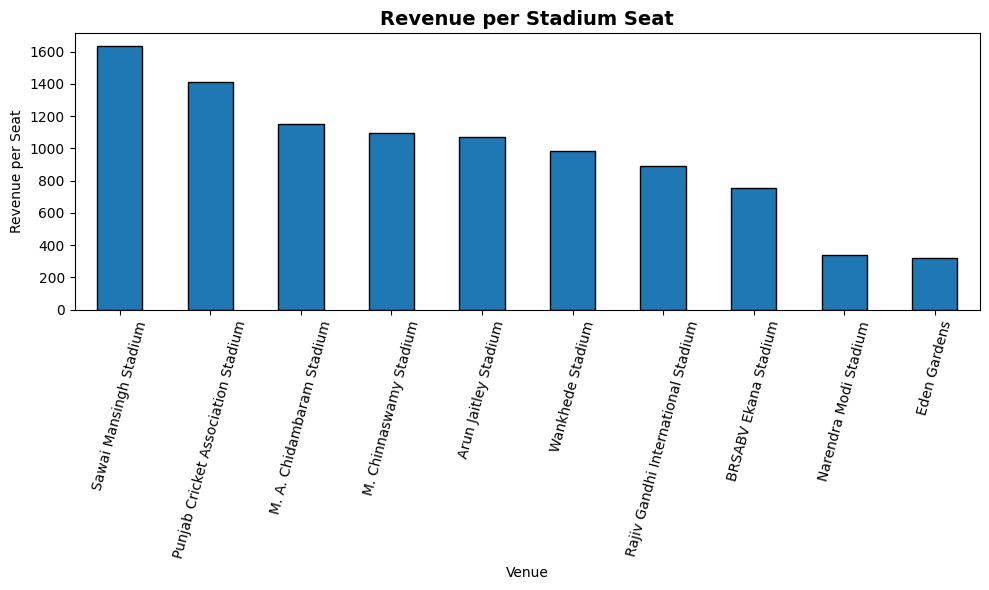

venue_revenue_efficiency.png saved successfully.


In [45]:
create_bar_chart(
    data=venue_efficiency.set_index("Venue")["Revenue_per_Seat"],
    title="Revenue per Stadium Seat",
    xlabel="Venue",
    ylabel="Revenue per Seat",
    filename="venue_revenue_efficiency.png",
    rotation=75
)

### Business Insight

Revenue efficiency highlights venues that maximize earnings relative to their seating capacity.

### Recommendation

Investigate operational and pricing strategies used at high-efficiency venues and apply similar practices to lower-performing stadiums.

## Query 19

### Business Question

Which home teams generate the highest ticket revenue?

### Objective

Determine which franchises contribute the most revenue through home fixtures.

In [46]:
home_team_revenue = (
    sales_data
    .groupby("Home_Team")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(home_team_revenue)

Home_Team
SRH     49142400
RR      48944000
GT      44540600
RCB     43767400
DC      43766800
CSK     43752200
PBKS    38114400
LSG     37777800
MI      32522800
KKR     21707600
Name: Total_Amount, dtype: int64

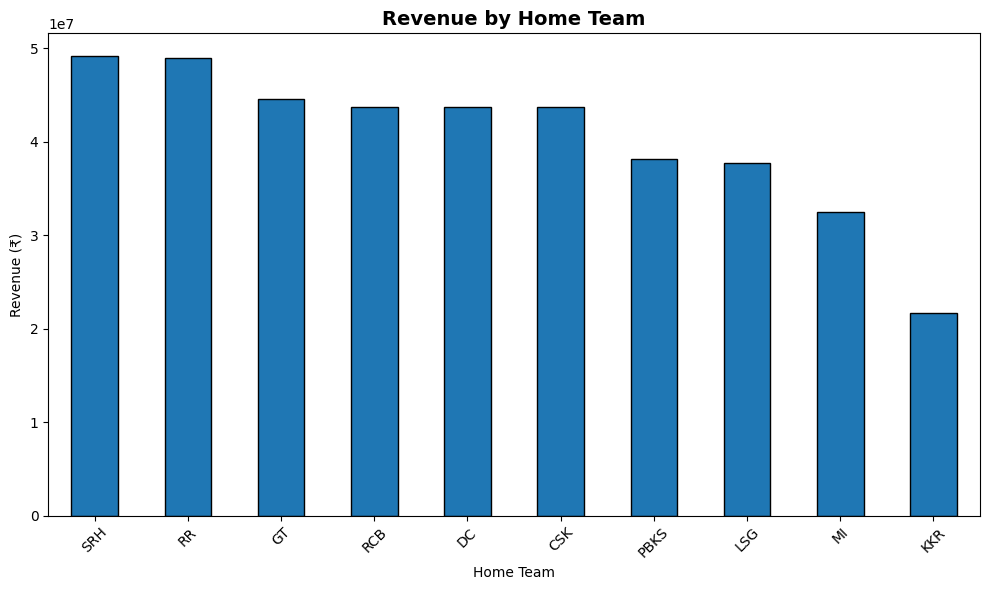

home_team_revenue.png saved successfully.


In [47]:
create_bar_chart(
    data=home_team_revenue,
    title="Revenue by Home Team",
    xlabel="Home Team",
    ylabel="Revenue (₹)",
    filename="home_team_revenue.png"
)

### Business Insight

Certain franchises consistently generate stronger ticket revenue due to larger fan bases and higher home match demand.

### Recommendation

Support lower-performing franchises with targeted marketing campaigns and local fan engagement initiatives.

## Query 20

### Business Question

How is ticket revenue distributed across different match types?

### Objective

Understand the variability in booking values for each match category.

<Figure size 1000x600 with 0 Axes>

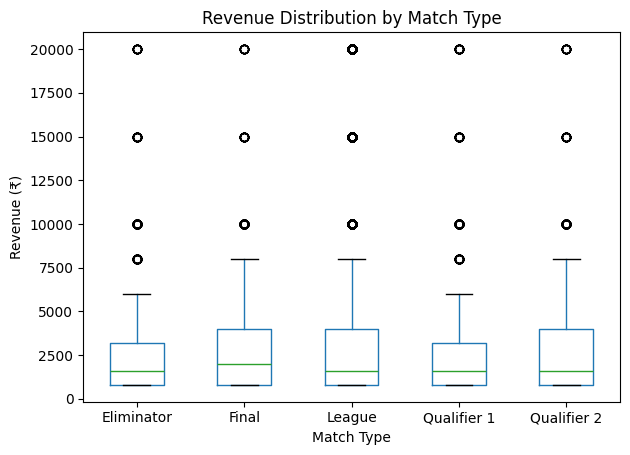

In [48]:
plt.figure(figsize=(10,6))

sales_data.boxplot(
    column="Total_Amount",
    by="Match_Type",
    grid=False
)

plt.title("Revenue Distribution by Match Type")
plt.suptitle("")
plt.xlabel("Match Type")
plt.ylabel("Revenue (₹)")

plt.tight_layout()

plt.savefig(
    CHARTS_FOLDER / "match_type_revenue_distribution.png",
    dpi=300
)

plt.show()

### Business Insight

Some match types exhibit greater variability in booking values, indicating differences in customer spending behavior and pricing strategies.

### Recommendation

Use revenue distribution insights to refine pricing models and promotional strategies for each match category rather than relying solely on average revenue.

### Business Insight

The correlation matrix helps identify variables that move together, revealing potential drivers of revenue and customer purchasing behaviour.

### Recommendation

Prioritize variables with strong positive relationships when developing pricing strategies and demand forecasting models.

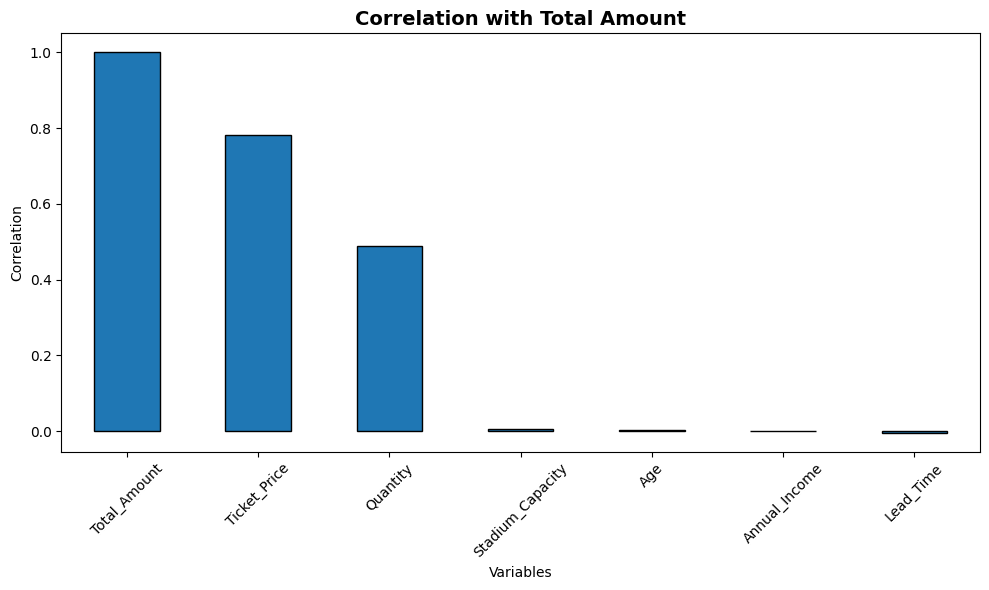

revenue_driver_analysis.png saved successfully.


In [55]:
create_bar_chart(
    data=revenue_driver,
    title="Correlation with Total Amount",
    xlabel="Variables",
    ylabel="Correlation",
    filename="revenue_driver_analysis.png",
    rotation=45
)

### Business Insight

Variables with higher positive correlations contribute more strongly to overall revenue and can be prioritized for strategic decision-making.

### Recommendation

Focus pricing, promotional campaigns, and operational planning around the strongest revenue-driving factors.

# Module 5 : Executive Business Intelligence & Statistical Analytics

## Objective

The objective of this module is to identify the key business drivers influencing IPL ticket revenue, evaluate customer purchasing behaviour, measure venue performance, and summarize executive-level KPIs that support strategic decision-making for franchise management.

## Query 21

### Business Question

Which business variables are most closely related to one another?

### Objective

To identify statistical relationships between important numerical variables using Pearson Correlation.

In [64]:
numeric_features = [

    "Ticket_Price",

    "Quantity",

    "Total_Amount",

    "Annual_Income",

    "Age",

    "Lead_Time",

    "Stadium_Capacity"

]

correlation = sales_data[numeric_features].corr()

display(correlation.round(2))

,Ticket_Price,Quantity,Total_Amount,Annual_Income,Age,Lead_Time,Stadium_Capacity
Ticket_Price,1.00,0.00,0.78,0.00,-0.00,-0.00,0.01
Quantity,0.00,1.00,0.49,0.00,0.01,-0.00,-0.00
Total_Amount,0.78,0.49,1.00,0.00,0.00,-0.00,0.00
Annual_Income,0.00,0.00,0.00,1.00,0.02,0.00,0.00
Age,-0.00,0.01,0.00,0.02,1.00,-0.00,-0.00
Lead_Time,-0.00,-0.00,-0.00,0.00,-0.00,1.00,-0.01
Stadium_Capacity,0.01,-0.00,0.00,0.00,-0.00,-0.01,1.00


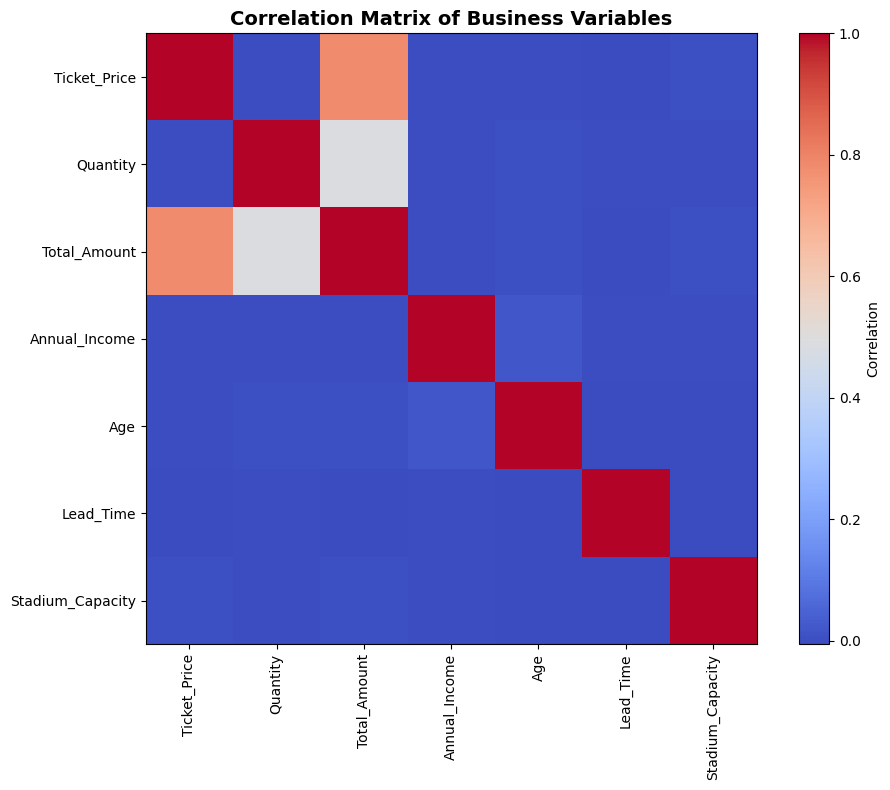

In [65]:
plt.figure(figsize=(10,8))

plt.imshow(
    correlation,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title(
    "Correlation Matrix of Business Variables",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    CHARTS_FOLDER /
    "business_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
display(
    correlation["Total_Amount"]
    .sort_values(ascending=False)
)

Total_Amount        1.000000
Ticket_Price        0.783083
Quantity            0.487787
Stadium_Capacity    0.004688
Age                 0.002965
Annual_Income       0.001073
Lead_Time          -0.003828
Name: Total_Amount, dtype: float64

### Key Observation

The strongest positive correlations indicate the variables that most influence ticket revenue.

### Business Insight

Ticket Price and Quantity have the strongest relationship with Total Amount because revenue is directly driven by ticket pricing and the number of tickets purchased.

### Recommendation

Pricing strategies and bundled ticket offers should focus on maximizing both ticket price optimization and average purchase quantity.

## Query 22

### Business Question

Which business factors contribute most to revenue generation?

### Objective

Rank important business variables based on their statistical relationship with revenue.

In [67]:
driver_rank = (

    correlation["Total_Amount"]

    .drop("Total_Amount")

    .abs()

    .sort_values(ascending=False)

)

driver_rank = driver_rank.reset_index()

driver_rank.columns = [

    "Business Driver",

    "Correlation Score"

]

driver_rank["Rank"] = range(
    1,
    len(driver_rank)+1
)

driver_rank

,Business Driver,Correlation Score,Rank
0,Ticket_Price,0.783083,1
1,Quantity,0.487787,2
2,Stadium_Capacity,0.004688,3
3,Lead_Time,0.003828,4
4,Age,0.002965,5
5,Annual_Income,0.001073,6


In [68]:
display(driver_rank)

,Business Driver,Correlation Score,Rank
0,Ticket_Price,0.783083,1
1,Quantity,0.487787,2
2,Stadium_Capacity,0.004688,3
3,Lead_Time,0.003828,4
4,Age,0.002965,5
5,Annual_Income,0.001073,6


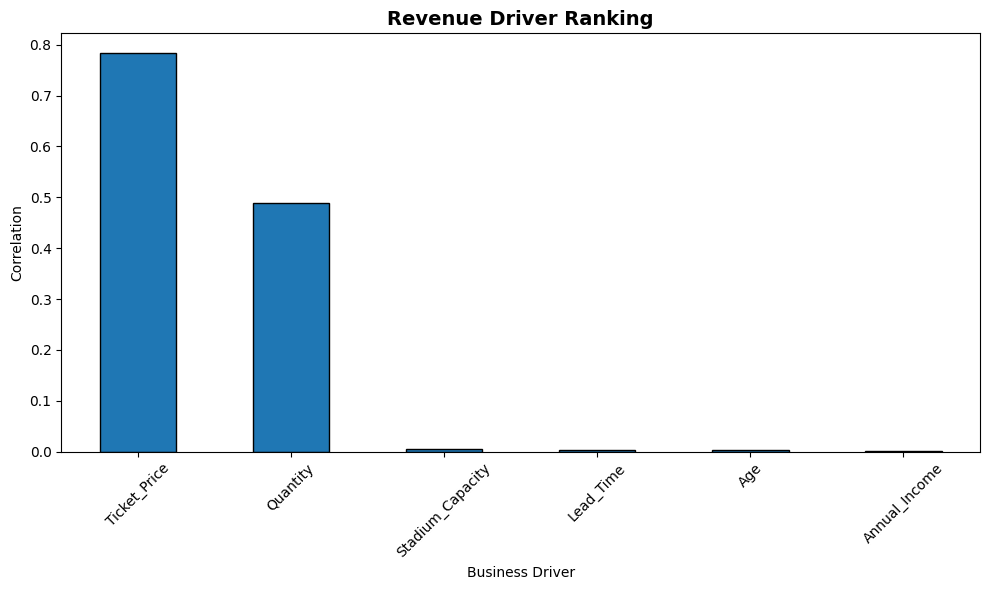

revenue_driver_ranking.png saved successfully.


In [69]:
create_bar_chart(

    driver_rank.set_index("Business Driver")["Correlation Score"],

    "Revenue Driver Ranking",

    "Business Driver",

    "Correlation",

    "revenue_driver_ranking.png"

)

### Business Insight

Revenue is influenced by multiple business factors, but some variables contribute significantly more than others.

### Recommendation

Prioritize high-impact business drivers when designing pricing models, promotional campaigns, and revenue optimization strategies.

## Query 23

### Business Question

Which customer income groups generate the highest revenue and average spending?

### Objective

To identify high-value customer income segments and support targeted marketing strategies.

In [70]:
sales_data["Income_Group"] = pd.cut(
    sales_data["Annual_Income"],
    bins=[0,500000,1000000,2000000,3000000,5000000],
    labels=[
        "Below 5L",
        "5L - 10L",
        "10L - 20L",
        "20L - 30L",
        "Above 30L"
    ]
)

display(sales_data[["Annual_Income","Income_Group"]].head())

,Annual_Income,Income_Group
0,329967,Below 5L
1,467400,Below 5L
2,516254,5L - 10L
3,2192494,20L - 30L
4,490251,Below 5L


In [71]:
income_summary = (
    sales_data
    .groupby("Income_Group")
    .agg(
        Customers=("Customer_ID","nunique"),
        Total_Revenue=("Total_Amount","sum"),
        Average_Spending=("Total_Amount","mean"),
        Average_Ticket_Price=("Ticket_Price","mean")
    )
    .round(2)
)

display(income_summary)

C:\Users\venka\AppData\Local\Temp\ipykernel_26708\2571294193.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Income_Group")


,Customers,Total_Revenue,Average_Spending,Average_Ticket_Price
Income_Group,,,,
Below 5L,2018,67447200,2688.53,1580.36
5L - 10L,5012,168542600,2686.41,1582.58
10L - 20L,3489,117436200,2701.73,1585.66
20L - 30L,926,31920800,2721.76,1595.48
Above 30L,555,18689200,2677.92,1584.67


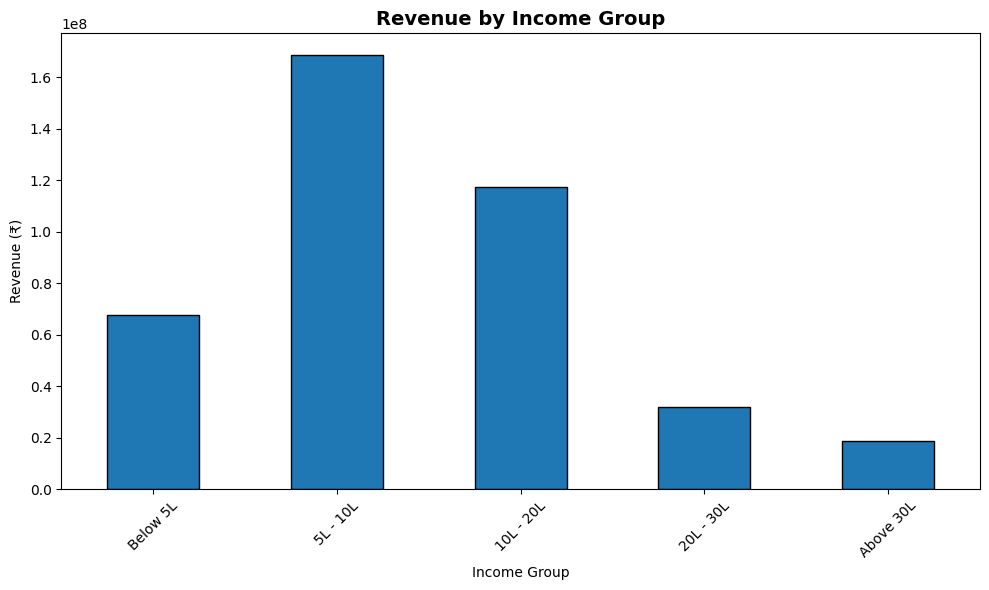

income_group_revenue.png saved successfully.


In [72]:
create_bar_chart(

    income_summary["Total_Revenue"],

    "Revenue by Income Group",

    "Income Group",

    "Revenue (₹)",

    "income_group_revenue.png"
)

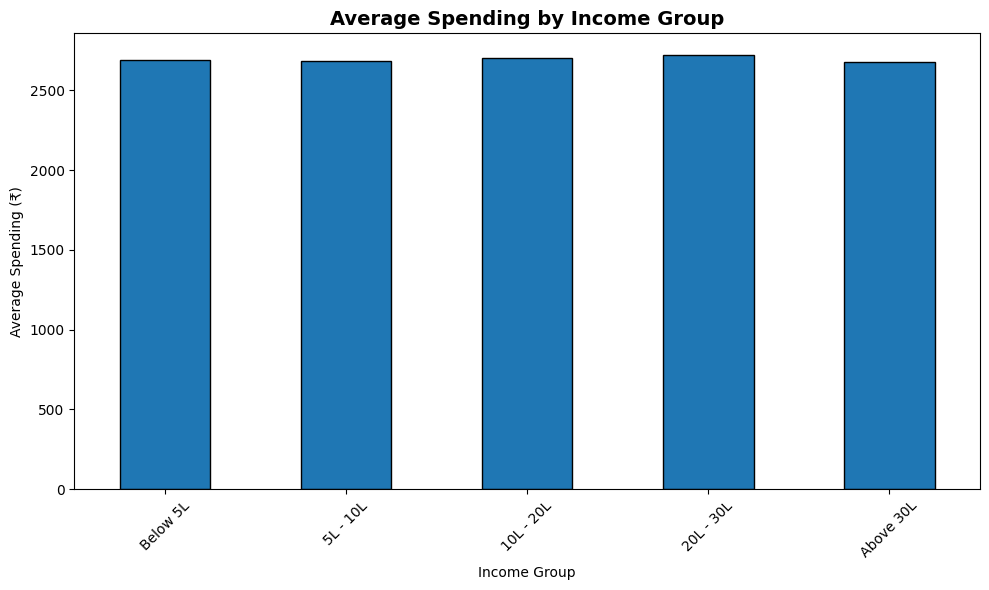

income_group_average_spending.png saved successfully.


In [73]:
create_bar_chart(

    income_summary["Average_Spending"],

    "Average Spending by Income Group",

    "Income Group",

    "Average Spending (₹)",

    "income_group_average_spending.png"
)

### Business Insight

Higher-income customers generally contribute greater revenue and exhibit higher average spending per booking, making them valuable targets for premium offerings and loyalty programs.

### Recommendation

Develop premium memberships, VIP experiences, and personalized promotions for higher-income customer segments while designing affordable campaigns to grow engagement among lower-income groups.

## Query 24

### Business Question

Which IPL venues deliver the best business performance?

### Objective

Evaluate venue performance using revenue, capacity, booking volume, and revenue efficiency.

In [76]:
venue_scorecard = (
    sales_data
    .groupby("Venue")
    .agg(
        Revenue=("Total_Amount", "sum"),
        Bookings=("Customer_ID", "count"),
        Capacity=("Stadium_Capacity", "first"),
        Avg_Ticket_Price=("Ticket_Price", "mean")
    )
)

venue_scorecard["Revenue_per_Seat"] = (
    venue_scorecard["Revenue"]
    / venue_scorecard["Capacity"]
)

venue_scorecard["Revenue_Rank"] = (
    venue_scorecard["Revenue"]
    .rank(
        ascending=False,
        method="dense"
    )
)

venue_scorecard = venue_scorecard.sort_values(
    by="Revenue",
    ascending=False
)

display(venue_scorecard)

,Revenue,Bookings,Capacity,Avg_Ticket_Price,Revenue_per_Seat,Revenue_Rank
Venue,,,,,,
Rajiv Gandhi International Stadium,49142400,18139,55000,1587.783230,893.498182,1.0
Sawai Mansingh Stadium,48944000,18042,30000,1578.184237,1631.466667,2.0
Narendra Modi Stadium,44540600,16316,132000,1600.637411,337.428788,3.0
M. Chinnaswamy Stadium,43767400,16468,40000,1574.811756,1094.185000,4.0
Arun Jaitley Stadium,43766800,16206,41000,1587.708256,1067.482927,5.0
M. A. Chidambaram Stadium,43752200,16318,38000,1587.633288,1151.373684,6.0
Punjab Cricket Association Stadium,38114400,14243,27000,1577.055396,1411.644444,7.0
BRSABV Ekana Stadium,37777800,14154,50000,1576.939381,755.556000,8.0
Wankhede Stadium,32522800,12087,33000,1580.193596,985.539394,9.0


In [75]:
sales_data.columns.tolist()

['Ticket_ID',
 'Customer_ID',
 'Match_ID',
 'Booking_Date',
 'Seat_Category',
 'Ticket_Price',
 'Quantity',
 'Total_Amount',
 'Payment_Method',
 'Booking_Status',
 'Match_Date',
 'Season',
 'Home_Team',
 'Away_Team',
 'Venue',
 'City_x',
 'Match_Type',
 'Stadium_Capacity',
 'VIP_Capacity',
 'Premium_Capacity',
 'Economy_Capacity',
 'First_Name',
 'Last_Name',
 'Gender',
 'Age',
 'Date_of_Birth',
 'City_y',
 'State',
 'Favorite_Team',
 'Occupation',
 'Annual_Income',
 'Loyalty_Tier',
 'Email',
 'Phone',
 'Registration_Date',
 'Lead_Time',
 'Lead_Time_Bucket',
 'Booking_Month',
 'Income_Group']

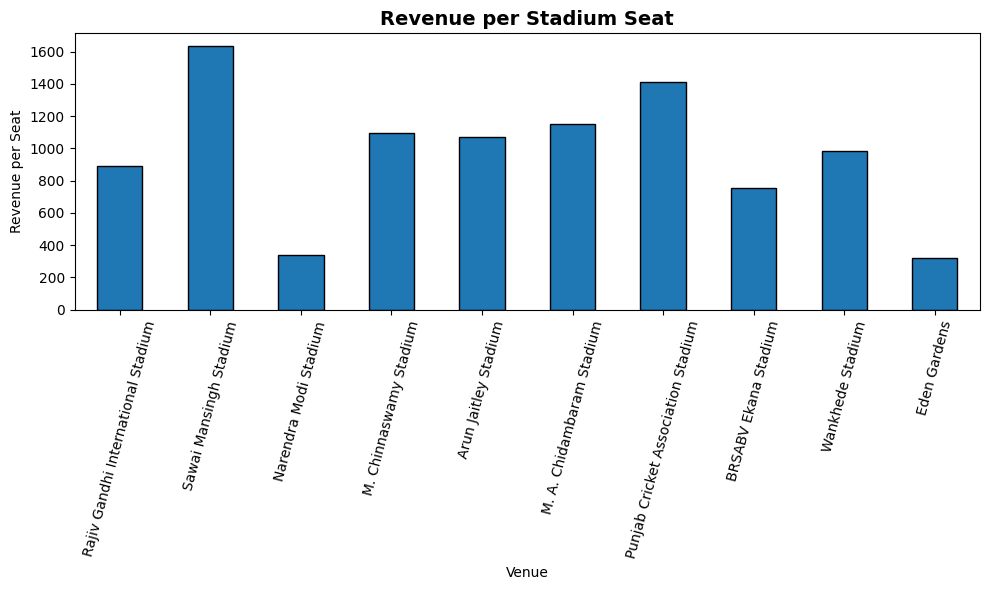

venue_revenue_per_seat.png saved successfully.


In [77]:
create_bar_chart(

    venue_scorecard["Revenue_per_Seat"],

    "Revenue per Stadium Seat",

    "Venue",

    "Revenue per Seat",

    "venue_revenue_per_seat.png",

    rotation=75
)

In [78]:
top3 = venue_scorecard.head(3)

display(top3)

,Revenue,Bookings,Capacity,Avg_Ticket_Price,Revenue_per_Seat,Revenue_Rank
Venue,,,,,,
Rajiv Gandhi International Stadium,49142400,18139,55000,1587.783230,893.498182,1.0
Sawai Mansingh Stadium,48944000,18042,30000,1578.184237,1631.466667,2.0
Narendra Modi Stadium,44540600,16316,132000,1600.637411,337.428788,3.0


### Business Insight

Revenue efficiency differs across venues even when stadium capacities are similar. High-performing venues combine strong demand, effective pricing, and higher booking volumes.

### Recommendation

Adopt pricing, marketing, and operational strategies from top-performing venues to improve revenue efficiency across the remaining stadiums.

In [82]:
# Rename duplicate columns after merge

sales_data = sales_data.rename(columns={
    "City_x": "Match_City",
    "City_y": "Customer_City"
})

display(sales_data.head())

,Ticket_ID,Customer_ID,Match_ID,Booking_Date,Seat_Category,Ticket_Price,Quantity,Total_Amount,Payment_Method,Booking_Status,Match_Date,Season,Home_Team,Away_Team,Venue,Match_City,Match_Type,Stadium_Capacity,VIP_Capacity,Premium_Capacity,Economy_Capacity,First_Name,Last_Name,Gender,Age,Date_of_Birth,Customer_City,State,Favorite_Team,Occupation,Annual_Income,Loyalty_Tier,Email,Phone,Registration_Date,Lead_Time,Lead_Time_Bucket,Booking_Month,Income_Group
0,T000001,C10477,M009,2026-03-28,Economy,800,1,800,UPI,Confirmed,2026-04-05,IPL 2026,SRH,RR,Rajiv Gandhi International Stadium,Hyderabad,League,55000,3000,12000,40000,Netra,Narang,Female,33,1993-04-02,Bengaluru,Karnataka,KKR,Nurse,329967,Bronze,netra.narang790@outlook.com,8904618696,2024-09-12,8,8-15 Days,March,Below 5L
1,T000002,C11088,M039,2026-03-18,Premium,2000,1,2000,UPI,Confirmed,2026-05-05,IPL 2026,RCB,DC,M. Chinnaswamy Stadium,Bengaluru,League,40000,2500,9000,28500,Peter,Nath,Male,55,1971-11-12,Mohali,Punjab,RCB,Police Officer,467400,Silver,peter.nath759@outlook.com,7963916621,2024-06-24,48,30+ Days,March,Below 5L
2,T000003,C03583,M029,2026-04-10,Economy,800,1,800,UPI,Confirmed,2026-04-25,IPL 2026,KKR,SRH,Eden Gardens,Kolkata,League,68000,3500,15000,49500,Sanya,Grover,Female,19,2007-11-26,Bengaluru,Karnataka,SRH,Police Officer,516254,Silver,sanya.grover701@hotmail.com,6785351562,2025-03-04,15,8-15 Days,April,5L - 10L
3,T000004,C08929,M002,2026-03-02,Economy,800,2,1600,Debit Card,Confirmed,2026-03-29,IPL 2026,MI,RCB,Wankhede Stadium,Mumbai,League,33000,1800,7000,24200,Wriddhish,Rajagopalan,Male,36,1990-08-18,Hyderabad,Telangana,MI,Chartered Accountant,2192494,Silver,wriddhish.rajagopalan511@outlook.com,7430869547,2024-11-30,27,16-30 Days,March,20L - 30L
4,T000005,C02616,M036,2026-03-18,Economy,800,1,800,UPI,Confirmed,2026-05-02,IPL 2026,GT,RR,Narendra Modi Stadium,Ahmedabad,League,132000,6000,26000,100000,Saumya,Tailor,Female,52,1974-10-10,Lucknow,Uttar Pradesh,RR,Police Officer,490251,Silver,saumya.tailor783@hotmail.com,7739250144,2025-01-22,45,30+ Days,March,Below 5L


In [83]:
# ===============================
# Column Configuration
# ===============================

MATCH_CITY = "City_x"
CUSTOMER_CITY = "City_y"

BOOKING_COLUMN = "Ticket_ID"

REVENUE = "Total_Amount"

PRICE = "Ticket_Price"

LOYALTY = "Loyalty_Tier"

MATCH_TYPE = "Match_Type"

VENUE = "Venue"

SEAT = "Seat_Category"

## Query 25

### Business Question

What are the key business KPIs required by franchise executives?

### Objective

Summarize the most important business metrics into a single executive dashboard.

In [25]:
# ==========================================
# Executive KPI Dashboard
# ==========================================

# Overall KPIs

total_revenue = sales_data["Total_Amount"].sum()

total_customers = sales_data["Customer_ID"].nunique()

total_bookings = sales_data["Ticket_ID"].nunique()

total_tickets = sales_data["Quantity"].sum()

avg_booking = sales_data["Total_Amount"].mean()

avg_ticket_price = sales_data["Ticket_Price"].mean()

# Highest Revenue Venue

highest_revenue_venue = (
    sales_data
    .groupby("Venue")["Total_Amount"]
    .sum()
    .idxmax()
)

# Highest Revenue Match City

highest_revenue_city = (
    sales_data
    .groupby("City_x")["Total_Amount"]
    .sum()
    .idxmax()
)

# Highest Revenue Match Type

highest_revenue_match_type = (
    sales_data
    .groupby("Match_Type")["Total_Amount"]
    .sum()
    .idxmax()
)

# Highest Revenue Seat Category

highest_revenue_seat = (
    sales_data
    .groupby("Seat_Category")["Total_Amount"]
    .sum()
    .idxmax()
)

# Highest Revenue Loyalty Tier

highest_revenue_loyalty = (
    sales_data
    .groupby("Loyalty_Tier")["Total_Amount"]
    .sum()
    .idxmax()
)

# Highest Revenue Payment Method

highest_revenue_payment = (
    sales_data
    .groupby("Payment_Method")["Total_Amount"]
    .sum()
    .idxmax()
)

# Highest Revenue Home Team

highest_revenue_team = (
    sales_data
    .groupby("Home_Team")["Total_Amount"]
    .sum()
    .idxmax()
)

# Executive Dashboard

executive_dashboard = pd.DataFrame({

    "KPI":[

        "Total Revenue",

        "Total Customers",

        "Total Bookings",

        "Total Tickets Sold",

        "Average Booking Value",

        "Average Ticket Price",

        "Highest Revenue Venue",

        "Highest Revenue Match City",

        "Highest Revenue Match Type",

        "Highest Revenue Seat Category",

        "Highest Revenue Loyalty Tier",

        "Highest Revenue Payment Method",

        "Highest Revenue Home Team"

    ],

    "Value":[

        f"₹{total_revenue:,.0f}",

        total_customers,

        total_bookings,

        total_tickets,

        f"₹{avg_booking:,.2f}",

        f"₹{avg_ticket_price:,.2f}",

        highest_revenue_venue,

        highest_revenue_city,

        highest_revenue_match_type,

        highest_revenue_seat,

        highest_revenue_loyalty,

        highest_revenue_payment,

        highest_revenue_team

    ]

})

display(executive_dashboard)

,KPI,Value
0,Total Revenue,"₹404,036,000"
1,Total Customers,12000
2,Total Bookings,150000
3,Total Tickets Sold,254833
4,Average Booking Value,"₹2,693.57"
5,Average Ticket Price,"₹1,584.21"
6,Highest Revenue Venue,Rajiv Gandhi International Stadium
7,Highest Revenue Match City,Hyderabad
8,Highest Revenue Match Type,League
9,Highest Revenue Seat Category,Premium
